# ECDFS-DP2v2: pS from per-bin histogram fits (no smoothing)
This notebook mirrors `ECDFS-DP1v2.ipynb` but uses only the new DP2 data.
Available DP2 fields: **ECDFS** and **COSMOS** (no DP2 data for EDFS or SV95_25).

Motivation: the smooth fitting step (Task 2 in v1) may introduce
additional noise in the final pS estimates. By skipping it, each source gets
the mixture parameters of the CModel magnitude bin it falls into — a flat
bin-lookup with no interpolation.

In [1]:
## automatically reload any modules read below that might have changed (e.g. plots)
%reload_ext autoreload
%autoreload 2

In [2]:
from astropy.table import Table
import matplotlib.pyplot as plt
import os
import pandas as pd
from functools import partial
import numpy as np
import re
from astropy.coordinates import SkyCoord
from astropy import units as u

In [3]:
import sys
sys.path.append('../src')
import modelLocusTools as mlt 
import pipeline as pipl
import plotting as pl

In [4]:
import data_processing as dp
import dist_dens as dd
from config import *

---

In [5]:
field = pd.DataFrame({
    'Field Code': ['ECDFS', 'COSMOS'],
    'ra':  [53.09, 150.25],
    'dec': [-27.51, 2.23],
})

coords = SkyCoord(
    ra  = field['ra'].values * u.deg,
    dec = field['dec'].values * u.deg,
    frame='icrs'
)

field['l'] = coords.galactic.l.deg
field['b'] = coords.galactic.b.deg
field

,Field Code,ra,dec,l,b
0,ECDFS,53.09,-27.51,223.060137,-54.415378
1,COSMOS,150.25,2.23,236.898148,42.242097


---

In [6]:
c_coo_ECDFS  = SkyCoord(53.09, -27.51, unit='deg', frame='icrs')
c_coo_COSMOS = SkyCoord(150.25, 2.23, unit='deg', frame='icrs')
c_coo = [c_coo_ECDFS, c_coo_COSMOS]

# Loading the data

In [7]:
fields = ['DP2_ECDFS_objects', 'DP2_COSMOS_objects']
field_labels = ['ECDFS', 'COSMOS']
data = [pipl.load_csv_dp2(f'../data/{i}.fits') for i in fields]
data[1].head()

,objectId,coord_ra,coord_dec,ebv,refBand,refExtendedness,detect_fromBlend,detect_isIsolated,parentObjectId,u_psfFlux,...,y_extendedness_flag,y_blendedness,y_blendedness_flag,y_pixelFlags_inexact_psfCenter,g_cModelMag,g_cModelMagErr,r_cModelMag,r_cModelMagErr,i_cModelMag,i_cModelMagErr
0,788010362900318671,150.930472,1.488274,0.026183,b'i',0.0,False,True,0,37.689739,...,True,NaN,True,False,26.496537,0.158418,25.345144,0.070689,25.315547,0.105648
1,788010362900318679,150.941913,1.488350,0.026330,b'i',1.0,False,True,0,-15.317045,...,True,0.011235,True,False,28.788401,1.698518,28.704317,1.789533,25.905435,0.224598
2,788010362900318691,150.948242,1.488776,0.026455,b'i',1.0,False,True,0,-28.197121,...,True,0.000000,True,False,27.308365,0.334380,26.121324,0.143641,26.034796,0.205399
3,788010362900318707,150.963171,1.489260,0.026808,b'g',1.0,False,True,0,114.782349,...,True,NaN,True,False,25.462370,0.067000,25.327279,0.078824,25.417572,0.127100
4,788010362900318708,150.986988,1.489517,0.027286,b'i',1.0,False,True,0,504.678833,...,False,0.000000,False,False,24.042238,0.022368,23.527614,0.017884,23.137469,0.019768


In [8]:
field['total num objects'] = [len(data[i]) for i in range(len(fields))]
field['total num objects'] = field['total num objects'].astype(int)
field

,Field Code,ra,dec,l,b,total num objects
0,ECDFS,53.09,-27.51,223.060137,-54.415378,732402
1,COSMOS,150.25,2.23,236.898148,42.242097,865287


# Magnitude calculations

In [9]:
data_mag = [pipl.magnitude_calculations(i, i['ebv']*3.10/1.20) for i in data]
data_mag[0].head()

C:\Users\Nemal\AppData\Roaming\Python\Python314\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Nemal\AppData\Roaming\Python\Python314\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,objectId,coord_ra,coord_dec,ebv,refBand,refExtendedness,detect_fromBlend,detect_isIsolated,parentObjectId,u_psfFlux,...,z_psfRelErr,y_diff,y_psfRelErr,ug,gr,ri,iz,zy,gi,Ar
0,755368611450718607,53.870339,-28.264069,0.009906,b'i',1.0,False,True,0,-146.214035,...,0.219124,-0.298456,6.004529,NaN,0.389896,0.894170,0.789771,-2.204321,1.284066,0.025592
1,755368611450718618,53.911221,-28.263557,0.010324,b'i',1.0,False,True,0,-155.719330,...,0.373825,NaN,-5.118841,NaN,-0.043961,0.715757,0.356879,NaN,0.671796,0.026671
2,755368611450718619,53.909665,-28.263455,0.010325,b'i',1.0,False,True,0,290.921814,...,0.440887,0.694628,1.482334,-1.214183,1.038915,0.007553,-0.108162,1.243014,1.046467,0.026672
3,755368611450718634,53.860472,-28.263186,0.009755,b'i',0.0,False,True,0,-11.530412,...,0.346438,NaN,-0.497404,NaN,0.094620,0.250152,0.521030,NaN,0.344772,0.025200
4,755368611450718656,53.854941,-28.262432,0.009667,b'i',1.0,False,True,0,-209.525146,...,-1.332346,0.112528,0.920064,NaN,NaN,NaN,NaN,NaN,NaN,0.024973


# Compare color-magnitude diagrams for unresolved and resolved sources
# Unresolved objects are selected as mag$_{psf}$-mag$_{CModel} <$0.016  

row= 0 all: 286993  S: 21122  G: 265799
 for r<24:
       all: 128266  S: 10874  G: 117350


c:\Users\Nemal\Desktop\star-galaxy-separation\notebooks\../src\plotting.py:188: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfSB = dfB[dmag<=0.016]
c:\Users\Nemal\Desktop\star-galaxy-separation\notebooks\../src\plotting.py:189: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfGB = dfB[dmag>0.016]


row= 1 all: 312875  S: 26723  G: 286141
 for r<24:
       all: 144377  S: 16189  G: 128183


c:\Users\Nemal\Desktop\star-galaxy-separation\notebooks\../src\plotting.py:188: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfSB = dfB[dmag<=0.016]
c:\Users\Nemal\Desktop\star-galaxy-separation\notebooks\../src\plotting.py:189: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dfGB = dfB[dmag>0.016]


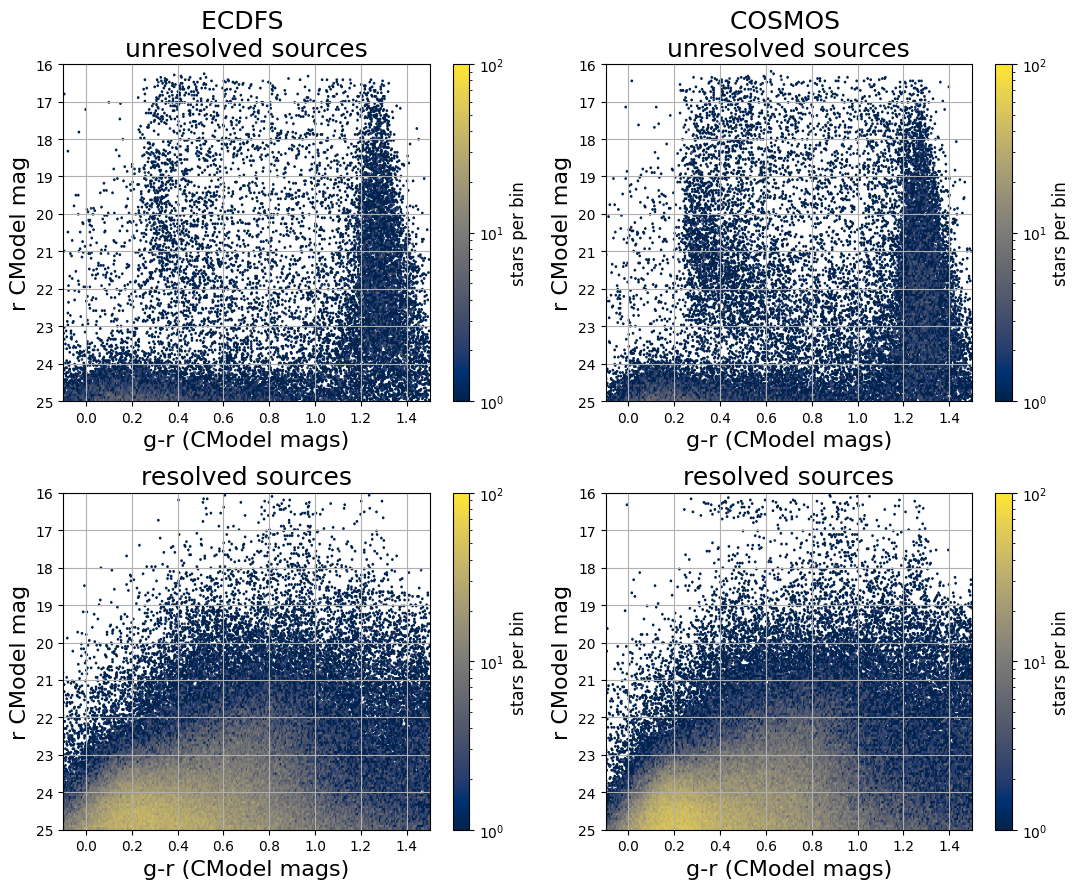

In [10]:
pl.plot_compareCMDs(data, 'compareCMDs_DP2v2_ECDFSandCOSMOS.png', fields=[0, 1],
                    field_names=['ECDFS', 'COSMOS'])

## Show mag$_{psf}$-mag$_{CModel}$ magnitude difference plots

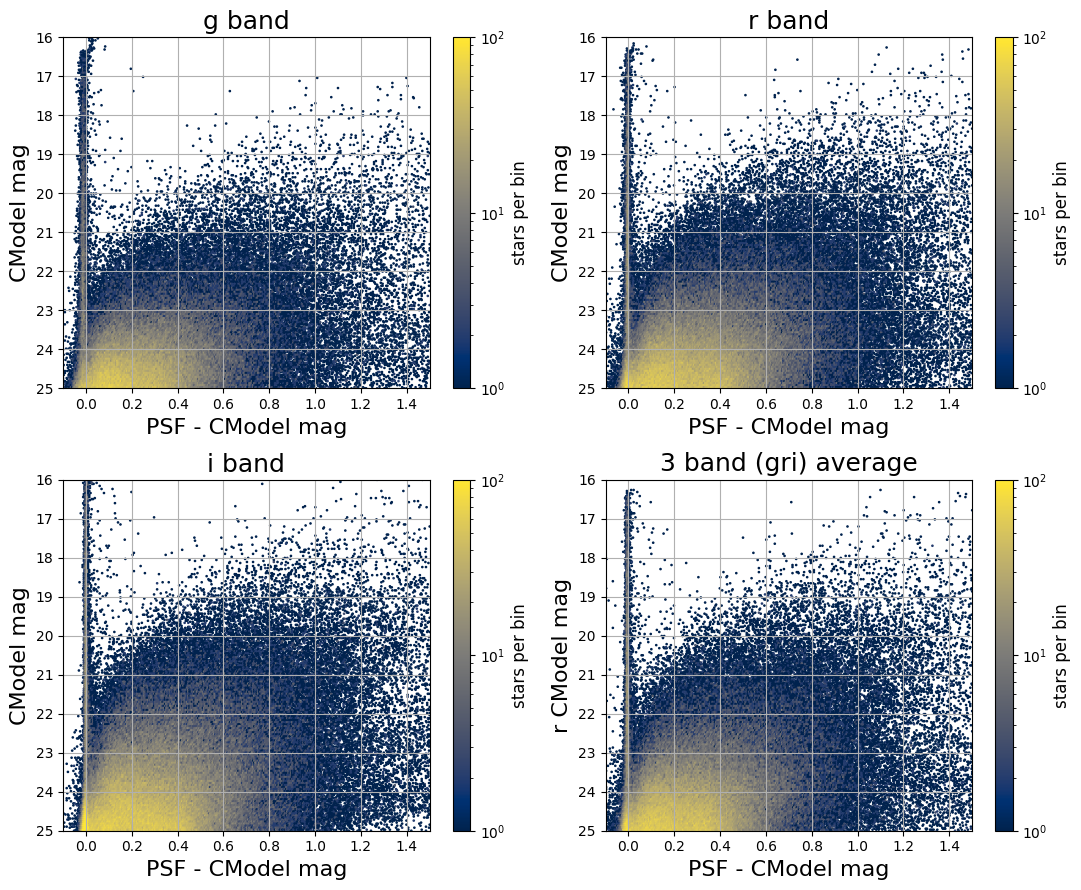

In [11]:
pl.plot_mag_diff(data[0], 'mag_diff_DP2v2_ECDFS.png')

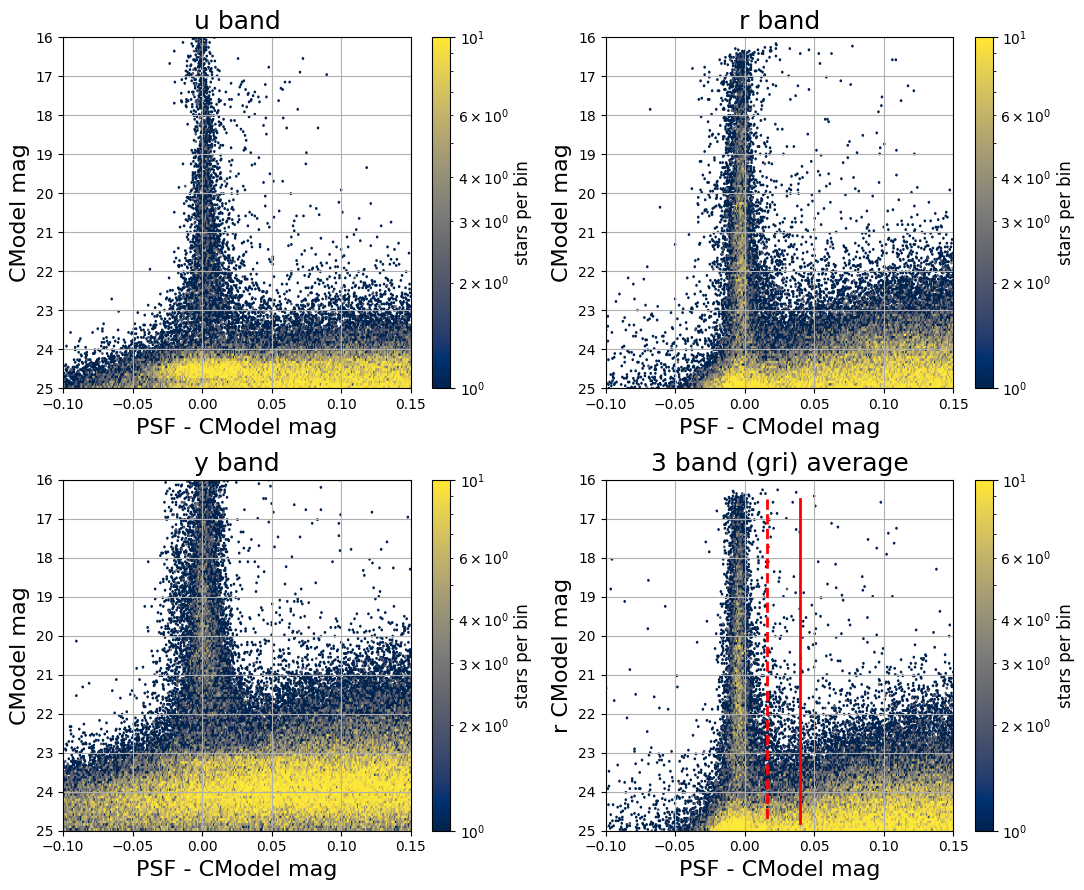

In [12]:
extent=[-0.1, 0.15, 14, 25]
cmap='cividis'
file_path='../plots/'
filters=['u', 'r', 'y']
pl.plot_mag_diff2(data[0], 'mag_diff_DP2v2_ECDFSzoom.png', extent=extent, cmap=cmap, file_path=file_path, filters=filters)

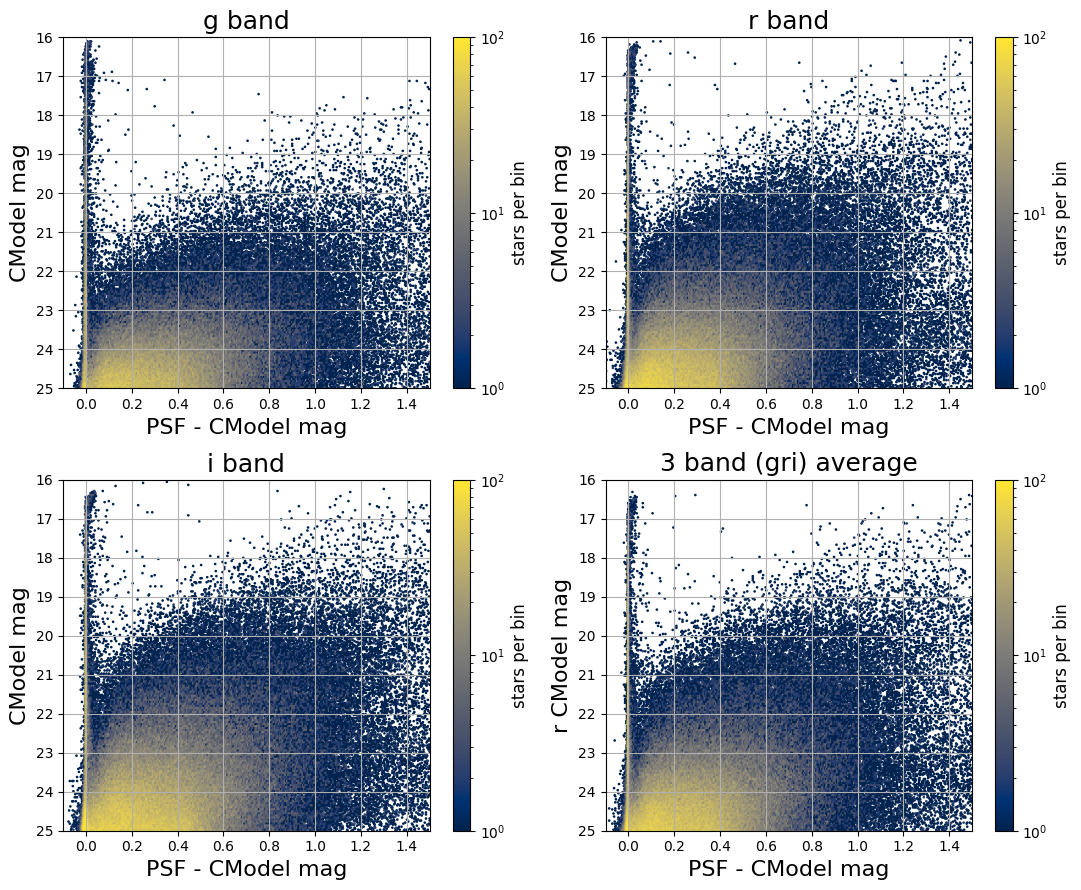

In [13]:
pl.plot_mag_diff(data[1], 'mag_diff_DP2v2_COSMOS.png')

## We want to limit the range for PSF-CModel from -0.5 to 1.5, and Cmodel mag to < 25
### (for DP1 dataset, eventually <27 for 10-year LSST).

## Show what how data (mosly junk) look beyond these limits:

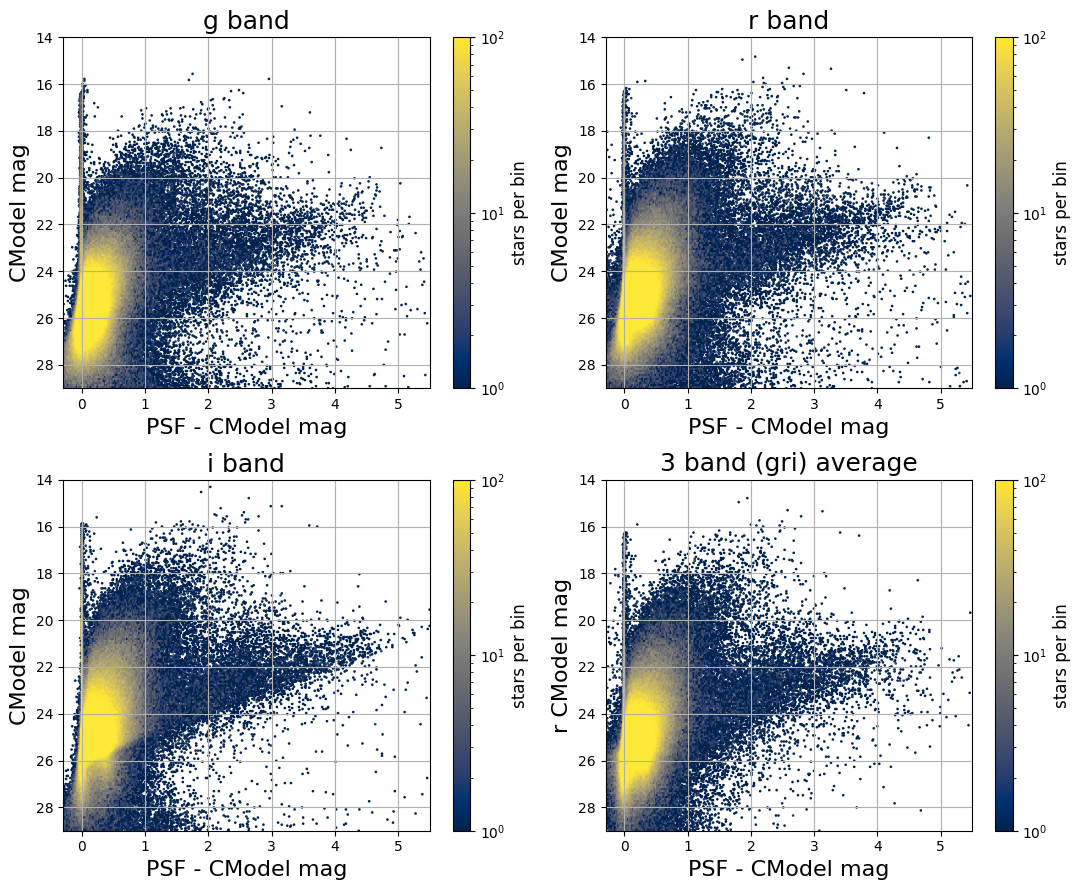

In [14]:
pl.plot_mag_diff(data[0], 'mag_diff_DP2v2_ECDFS_wide.png', extent=[-0.3, 5.5, 14, 29])

## Develop a tool to fit an arbitrary observed distribution in the CModel vs. PSF-CModel diagram using a two component model (in each filter, ugrizy, separately): 


### 1) first fit PSF-CModel histograms for slices of CModel using one Gaussian centered on 0 and 1-3 Gaussians to model extended sources; use these CModel bins: <18, 18-19, 19-20, 20-21, 21-22, 22-23, 23-24, 24-25; free model parameters are the width for the unresolved source distribution (location is fixed to 0), and parameters describing resolved source distribution. Show data histogram and the best fit model for each CModel bin.
### 2) using best-fit models for these CModel mag bins, test if the CModel dependence can be abstracted too using some convenient fitting form
### 3) using the final model, produce and plot 2D histogram for data distribution and make the 2D model and data-model residuals plot (similar to the two right panels in fig. 10 from http://faculty.washington.edu/ivezic/Publications/Slater_2020_AJ_159_65.pdf) 

### 4) given the best 2D model, return pS = (unresolved model component) / (total 2D model) for two input arrays of PSF-CModel and CModel. Test by providing the same arrays as for constructing the 2D model and plot the median pS per pixel in the CModel vs. PSF-CModel diagram. 


## Notes:

### The tool must take the ranges of PSF-CModel and CModel as inputs (defaults are  -0.5 to 1.5, and Cmodel mag from 15 to 25. 

### ECDFS field is good for developing this tool; COSMOS is good for testing. 


### For fitting a sum (mixture)  of Gaussians fitting, see 
https://www.astroml.org/book_figures/chapter4/fig_GMM_1D.html 

### For 2D histograms, see the right panel in https://www.astroml.org/book_figures/chapter4/fig_lyndenbell_toy.html

### The ultimate test will be using this tool on Rubin DP2 data for COSMOS field, and measuring performance using classification labels based on HST COSMOS data. The result of this measurement will look similar to fig. 11 from http://faculty.washington.edu/ivezic/Publications/Slater_2020_AJ_159_65.pdf.

### Import the new fitting tool

In [15]:
import psf_cmodel_fit as pcf

## Task 1: Fit PSF-CModel histograms in CModel slices (per filter)
One Gaussian at 0 for unresolved sources (sigma free) plus 2 resolved Gaussians (location, width, weight free). CModel bins: <18, 18-19, ..., 24-25.

--- fitting filter u ---


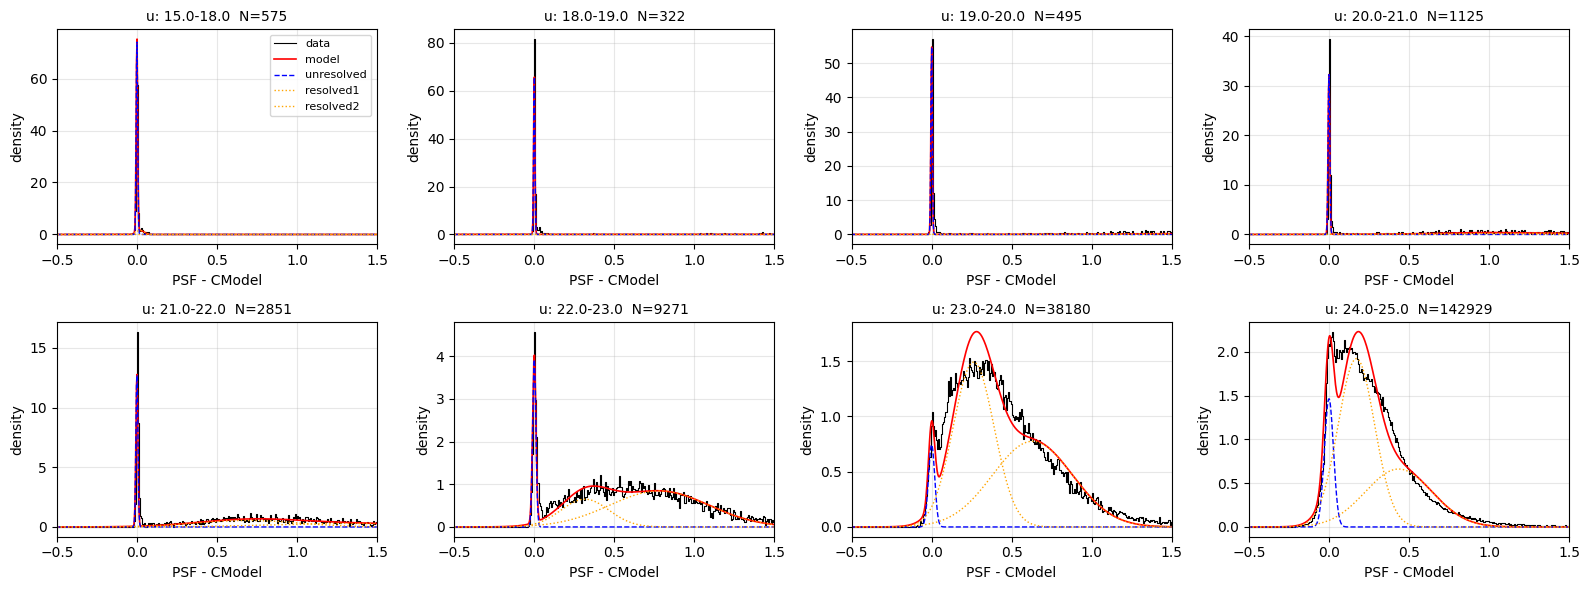

--- fitting filter g ---


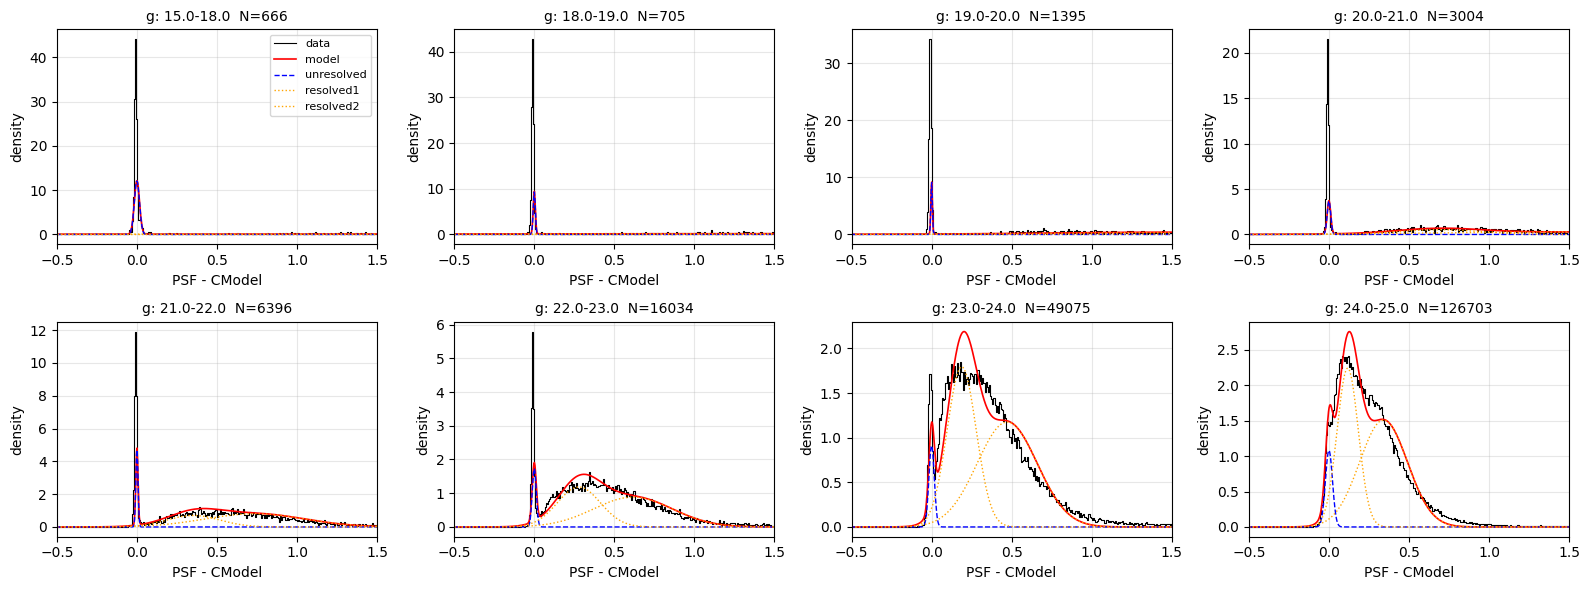

--- fitting filter r ---


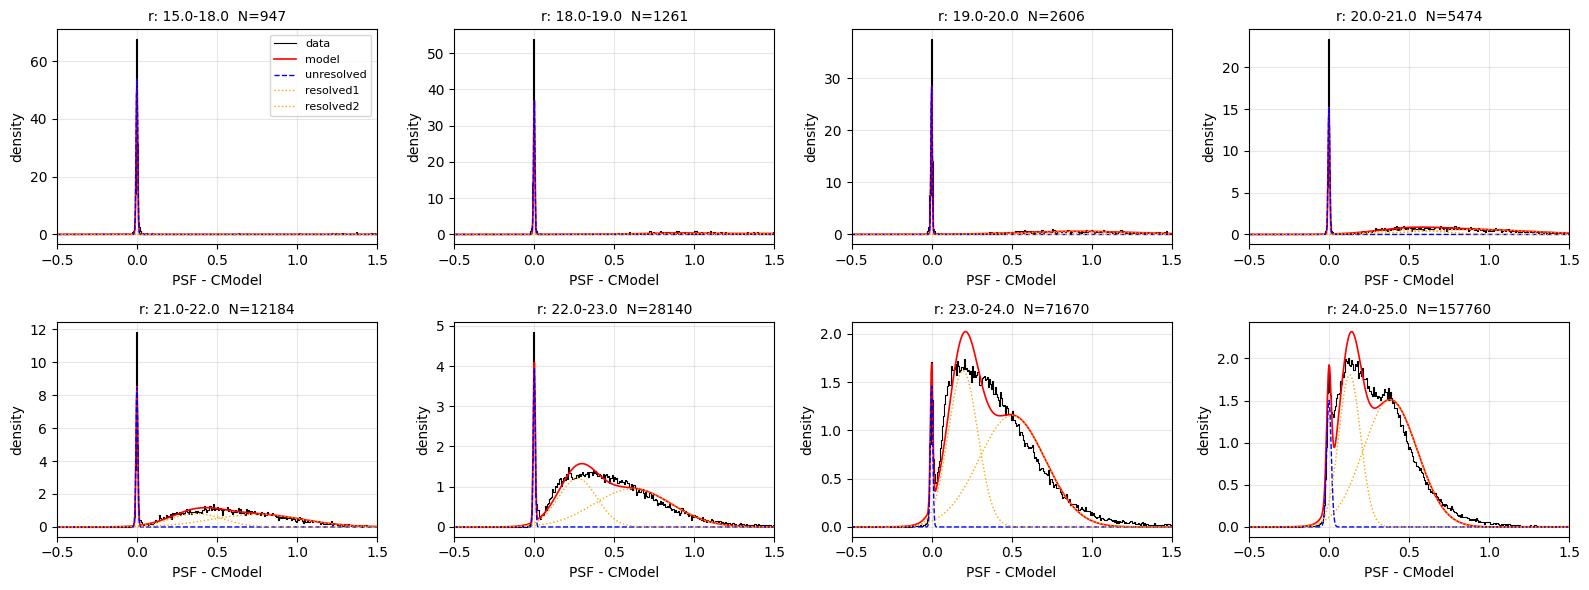

--- fitting filter i ---


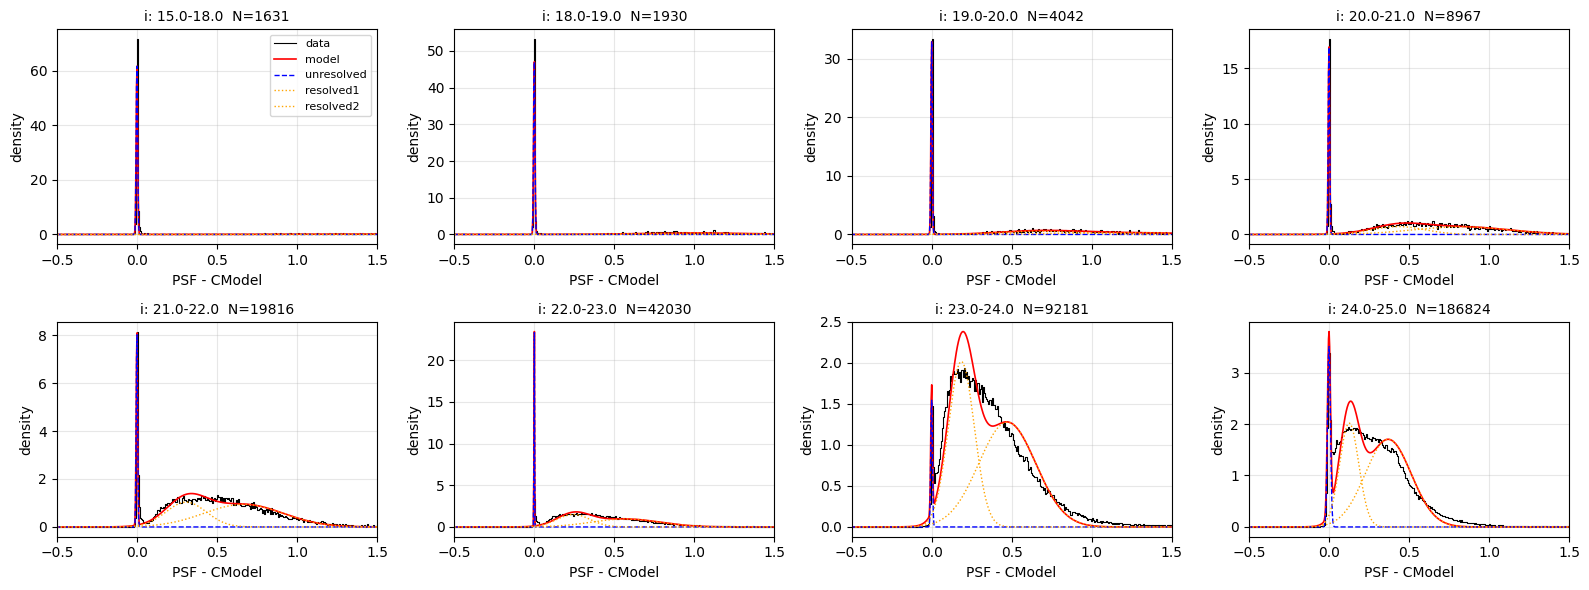

--- fitting filter z ---


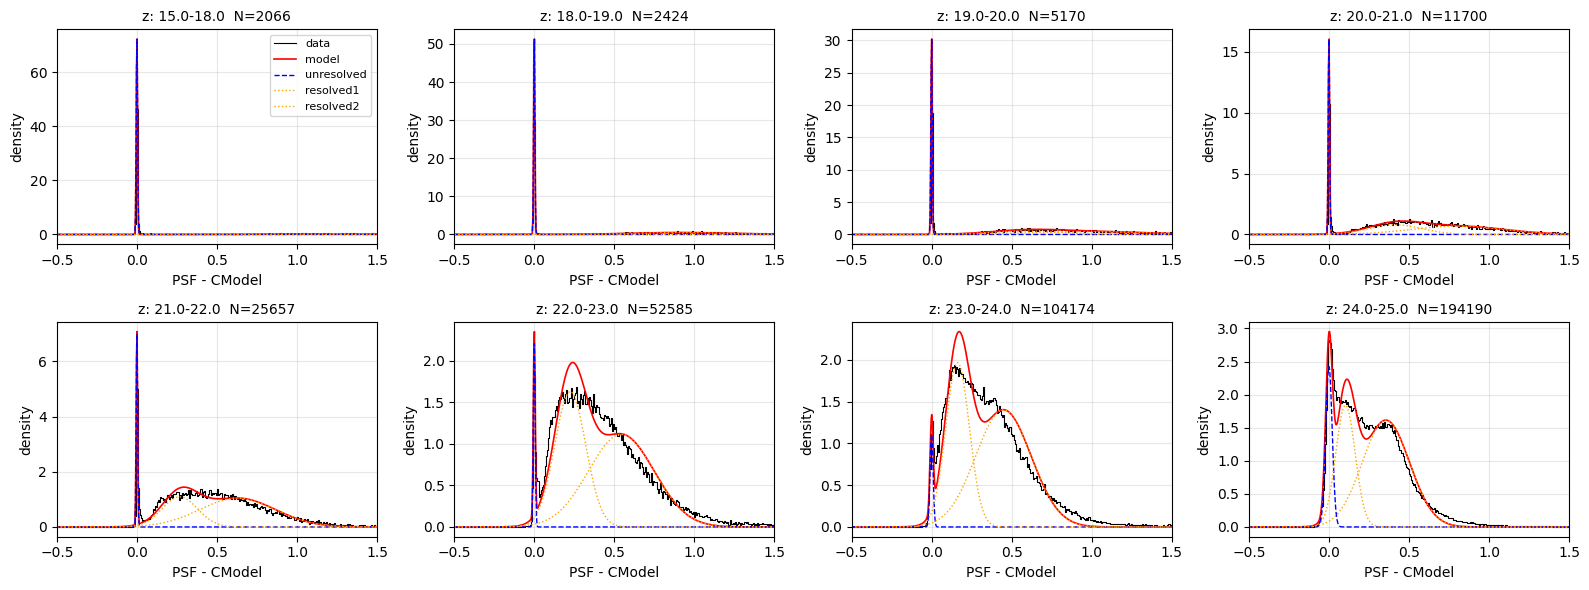

--- fitting filter y ---


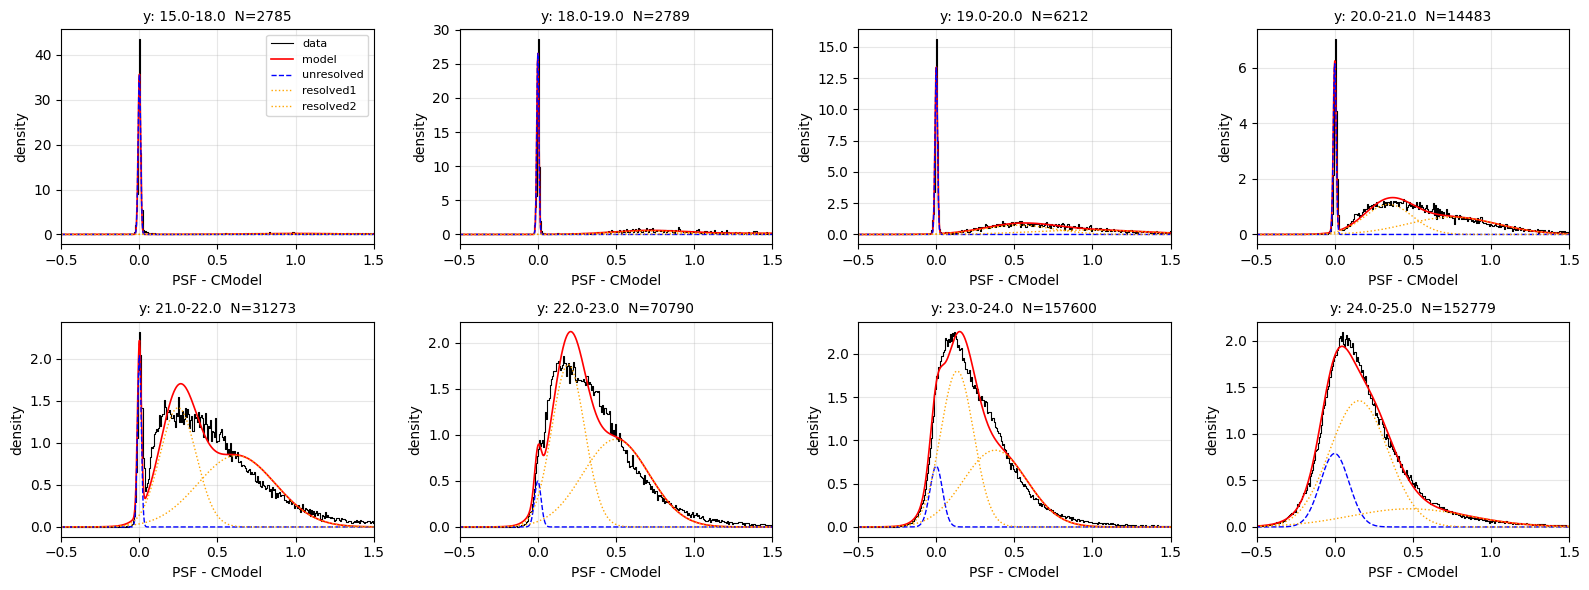

In [16]:
# ECDFS (data_mag[0]) is the development field.
# Two resolved Gaussians usually suffice; bump to 3 for worse-behaved bands.
slice_fits = {}
for band in ['u', 'g', 'r', 'i', 'z', 'y']:
    print(f'--- fitting filter {band} ---')
    slice_fits[band] = pcf.fit_slices(data_mag[0], band, n_resolved=2)
    pcf.plot_slice_fits(slice_fits[band], band,
                        name=f'slice_fits_DP2v2_ECDFS_{band}.png')

## Task 2: Using raw per-bin parameters instead of smooth fits
Instead of fitting Sesar eq. 5 and polynomials through the slice-fit values,
we build a binned model that uses the raw per-bin parameters from Task 1.
Each source gets the mixture parameters of the CModel magnitude bin it falls into.
No interpolation or smoothing is applied.

In [17]:
binned_models = {}
for band, fits in slice_fits.items():
    binned_models[band] = pcf.build_binned_model(fits)
    print(f'--- {band}: using raw per-bin parameters '
          f'({len([r for r in fits if r["success"]])} bins) ---')

--- u: using raw per-bin parameters (8 bins) ---
--- g: using raw per-bin parameters (8 bins) ---
--- r: using raw per-bin parameters (8 bins) ---
--- i: using raw per-bin parameters (8 bins) ---
--- z: using raw per-bin parameters (8 bins) ---
--- y: using raw per-bin parameters (8 bins) ---


## Task 3: 2D data, 2D model, and residuals
Three-panel plot per filter (cf. right panels of fig. 10 in Slater+ 2020).

--- 2D model vs data: u ---


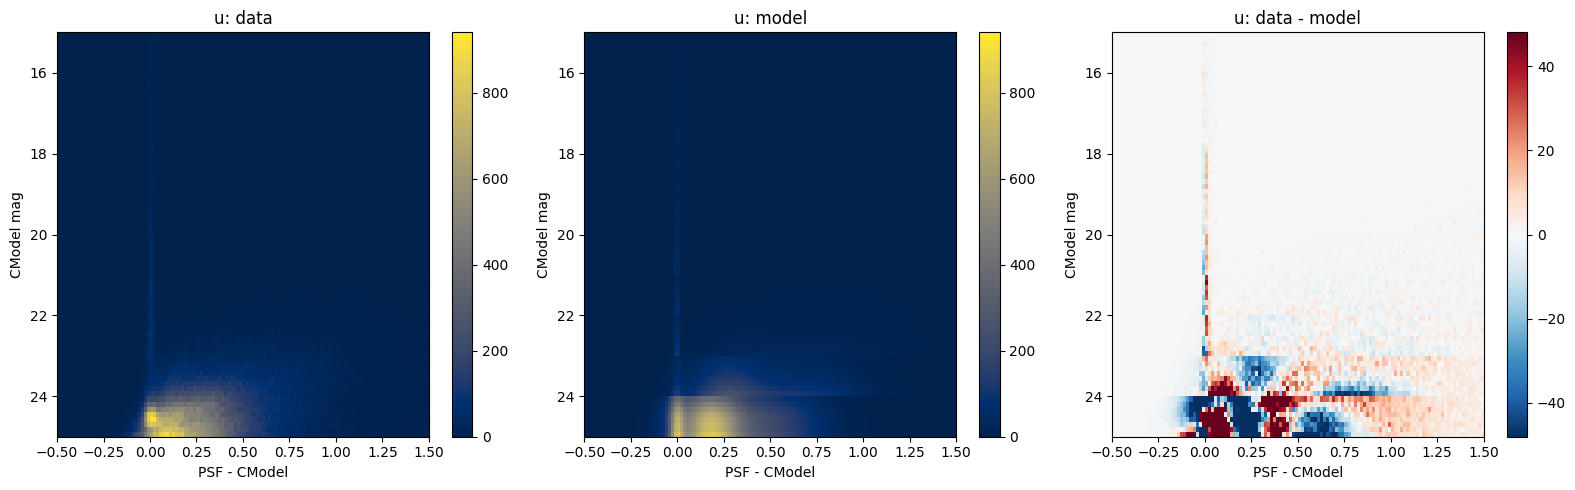

--- 2D model vs data: g ---


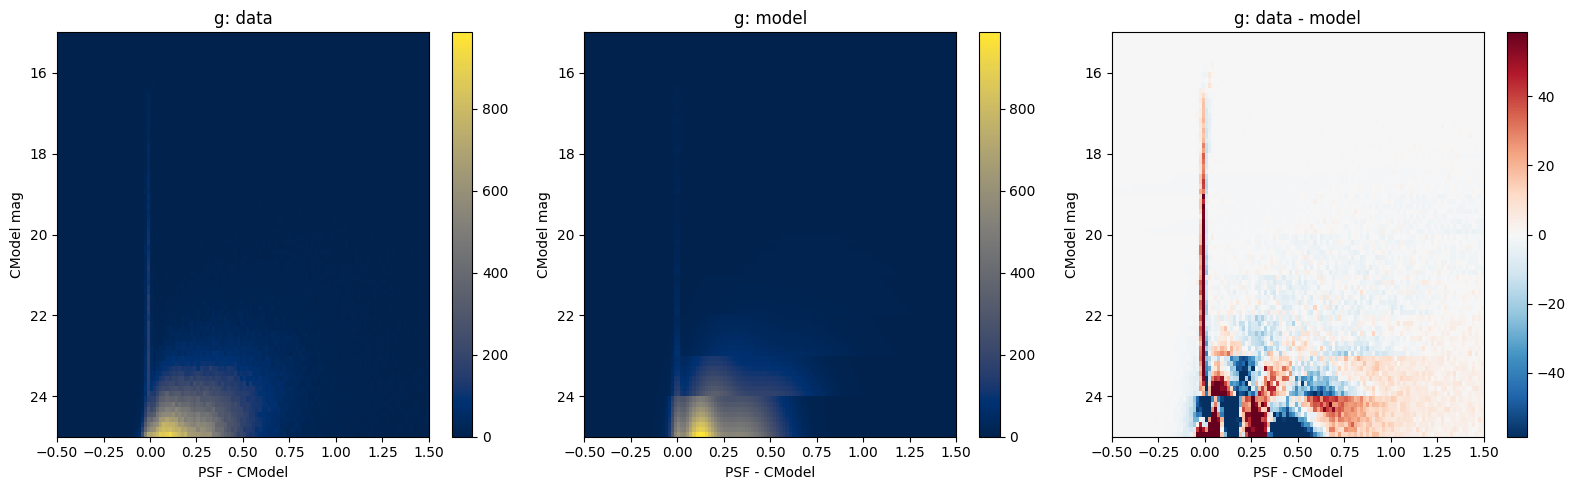

--- 2D model vs data: r ---


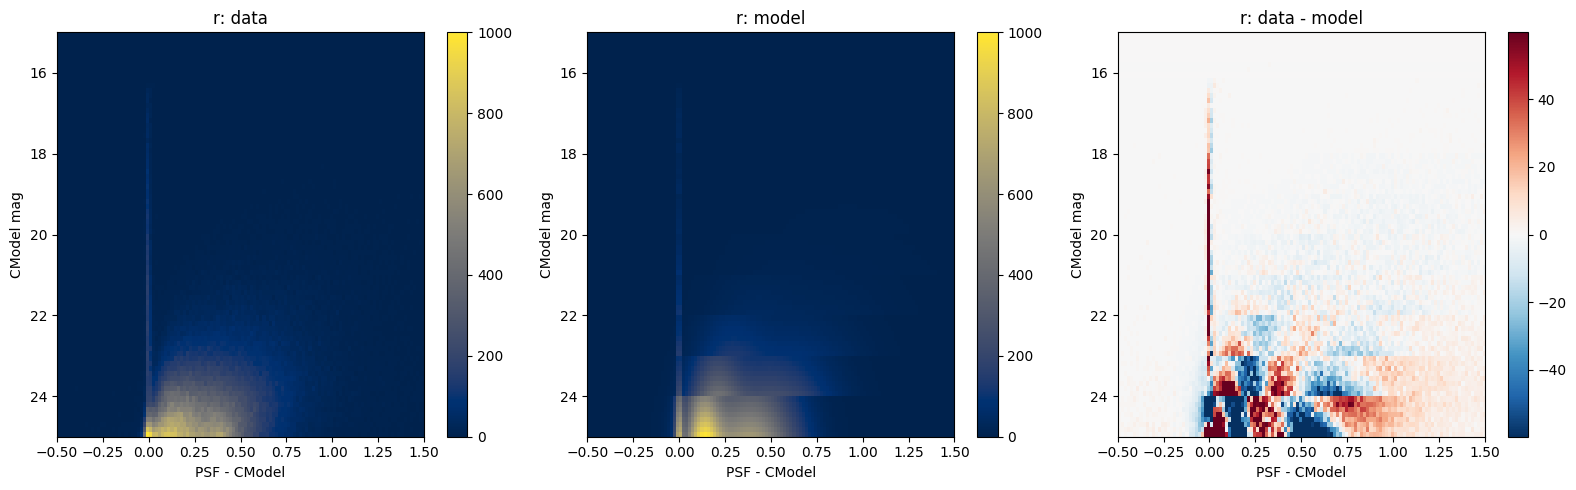

--- 2D model vs data: i ---


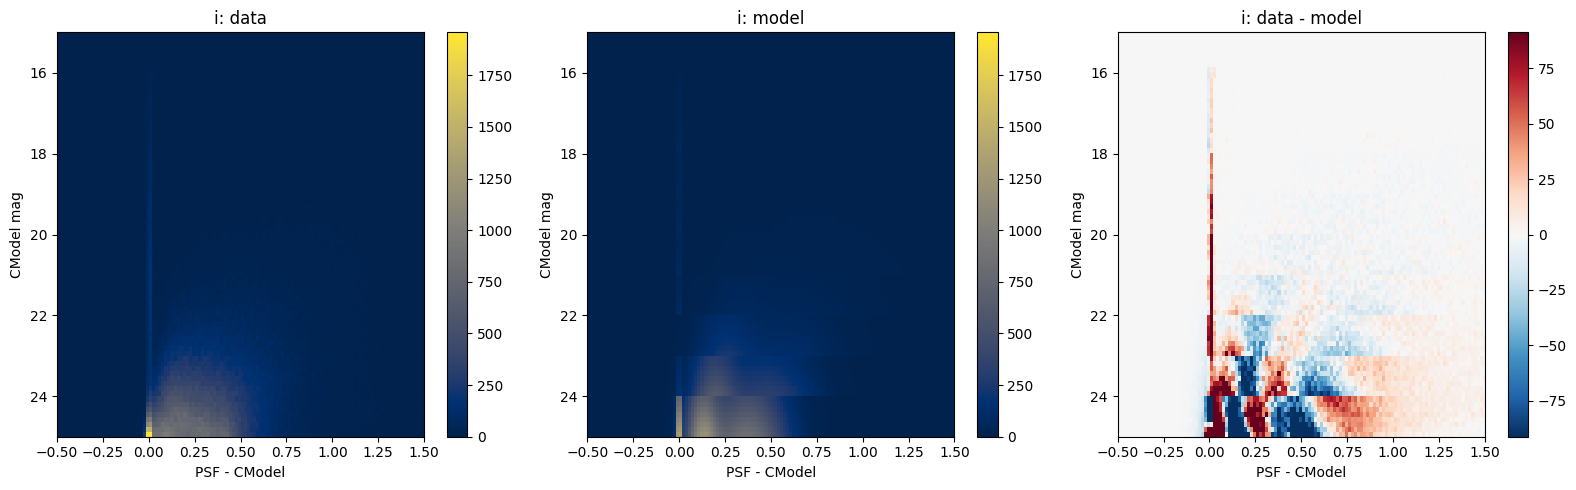

--- 2D model vs data: z ---


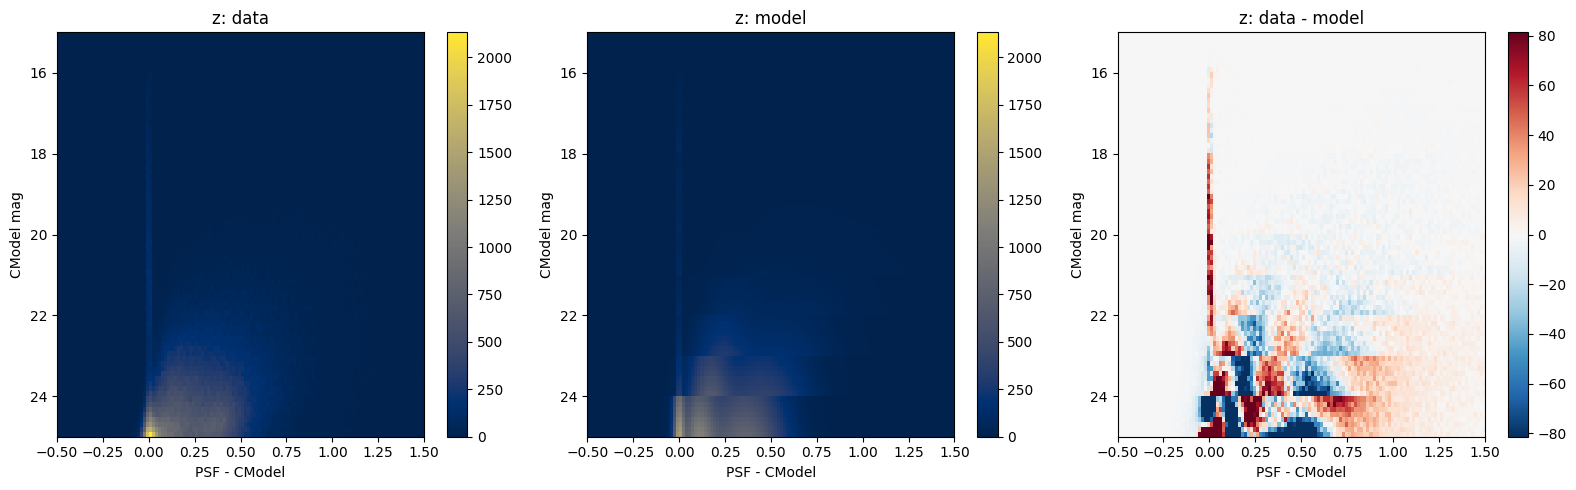

--- 2D model vs data: y ---


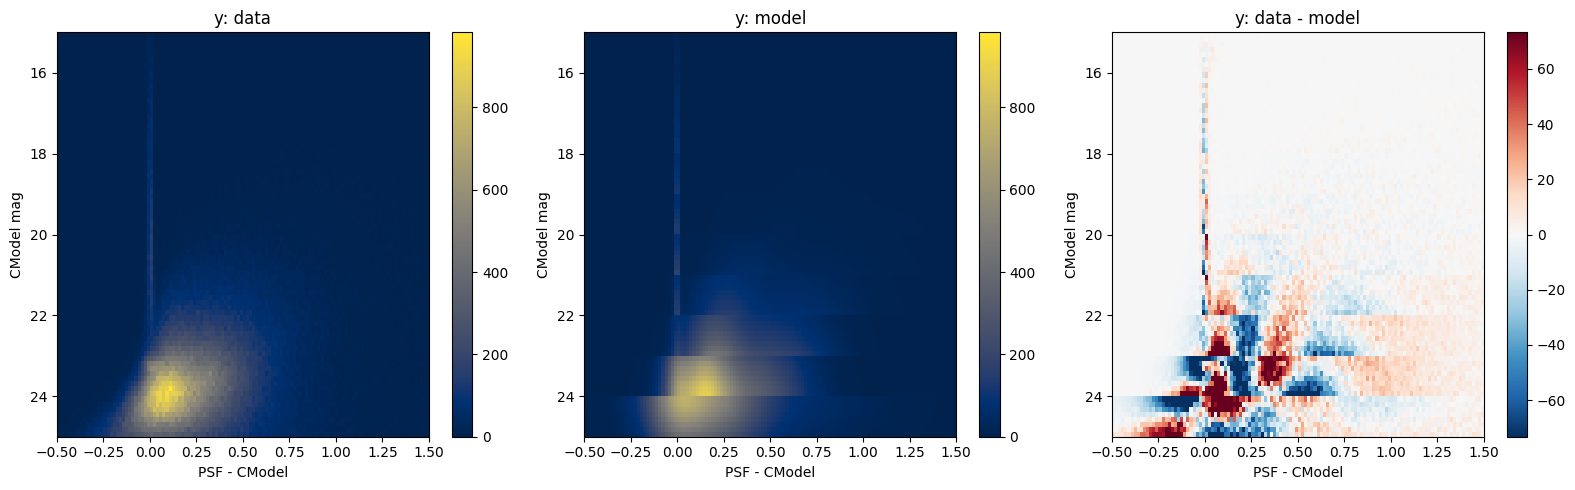

In [18]:
residuals_2d = {}
for band in ['u', 'g', 'r', 'i', 'z', 'y']:
    print(f'--- 2D model vs data: {band} ---')
    residuals_2d[band] = pcf.plot_2d_model_residuals(
        data_mag[0], band, binned_models[band],
        name=f'model2D_DP2v2_ECDFS_{band}.png')

## Task 4: pS = P(unresolved) / P(total) and its median-per-pixel map
pS is returned for arbitrary (PSF-CModel, CModel) input arrays. As a self-test we feed back the ECDFS photometry and plot the median pS per pixel.

--- pS map: u ---


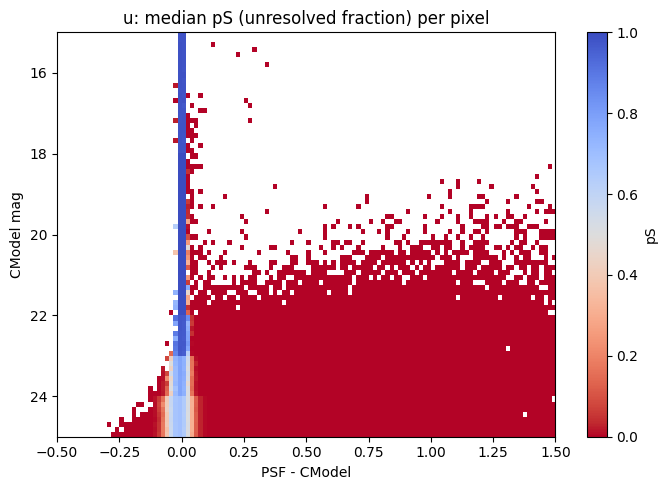

--- pS map: g ---


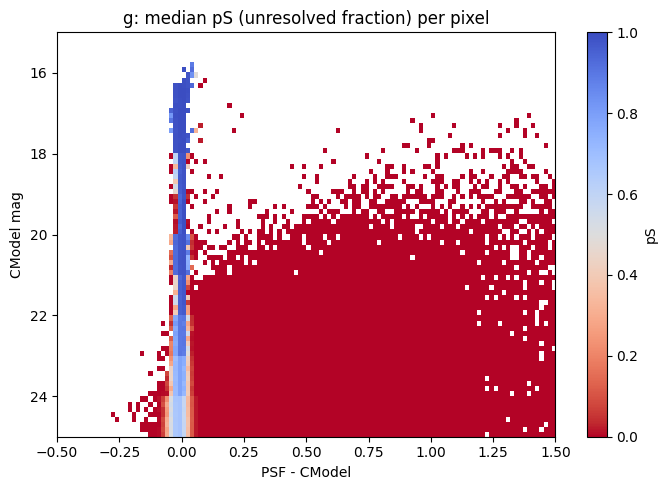

--- pS map: r ---


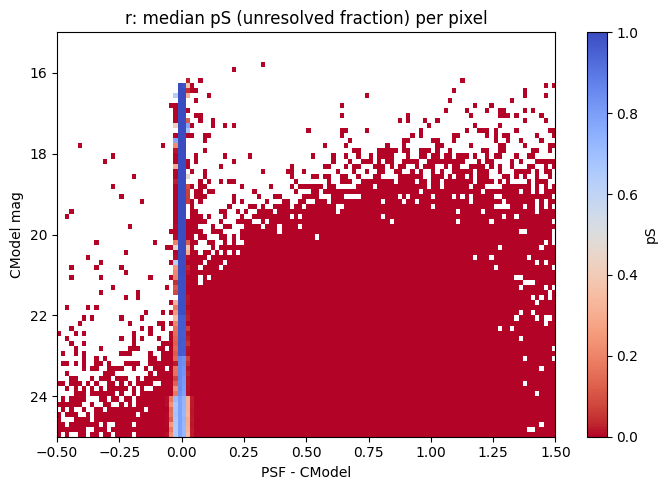

--- pS map: i ---


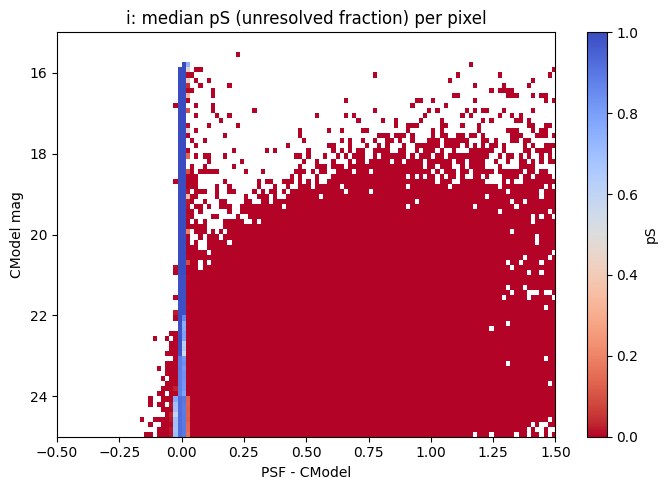

--- pS map: z ---


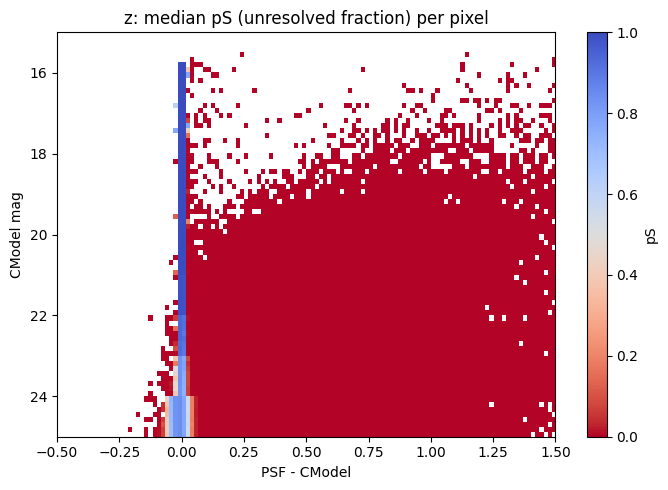

--- pS map: y ---


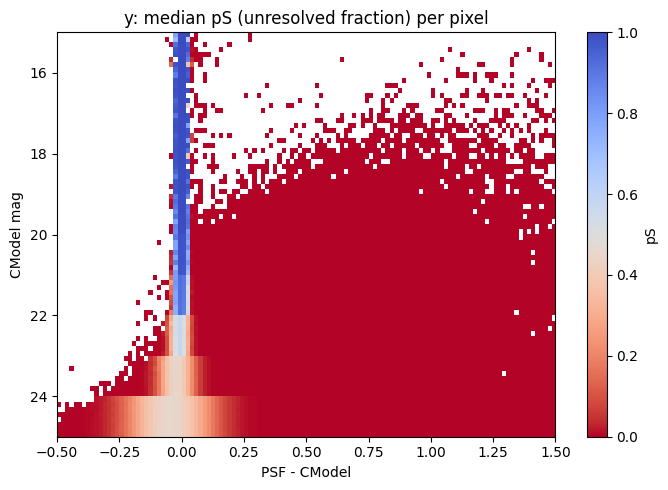

In [19]:
# Self-test: compute pS for the same arrays that built the 2D model
# and plot median pS per pixel in the CModel vs. PSF-CModel diagram.
pS_maps = {}
for band in ['u', 'g', 'r', 'i', 'z', 'y']:
    print(f'--- pS map: {band} ---')
    pS_maps[band] = pcf.plot_pS_map(
        data_mag[0], band, binned_models[band],
        name=f'pS_map_DP2v2_ECDFS_{band}.png')

In [20]:
# Sanity check: verify compute_pS works on arbitrary arrays too
dm_test = np.array([0.0, 0.05, 0.2, 0.8, 1.2])
cm_test = np.array([18.0, 20.0, 22.0, 23.0, 24.0])
pS_test = pcf.compute_pS(dm_test, cm_test, binned_models['r'])
for dm_v, cm_v, ps in zip(dm_test, cm_test, pS_test):
    print(f'PSF-CModel={dm_v:+.2f}, CModel={cm_v:.1f}  ->  pS={ps:.3f}')

PSF-CModel=+0.00, CModel=18.0  ->  pS=0.999
PSF-CModel=+0.05, CModel=20.0  ->  pS=0.000
PSF-CModel=+0.20, CModel=22.0  ->  pS=0.000
PSF-CModel=+0.80, CModel=23.0  ->  pS=0.000
PSF-CModel=+1.20, CModel=24.0  ->  pS=0.000


## EXTERNAL LABEL INTEGRATION WITH ALL AVAILABLE FILTERS
This add-on leaves the Rubin-side workflow above unchanged. It attaches the clean ECDFS HST/3D-HST matched labels to `data_mag[0]`, computes Rubin-side `pS` for every usable band in `u g r i z y`, and then saves the per-band external-label validation plots for each available filter.

In [21]:
import importlib
import sys

if 'external_label_tools' in sys.modules:
    del sys.modules['external_label_tools']

import external_label_tools as elt
elt = importlib.reload(elt)

if '_score_col_for_band' not in elt.__dict__:
    def _score_col_for_band(band, score_prefix='pS_', score_suffix=None):
        if score_suffix is not None:
            return f'{band}{score_suffix}'
        return f'{score_prefix}{band}'
    elt._score_col_for_band = _score_col_for_band

from pathlib import Path

MATCHED_LABEL_PATH = Path('../data/hst_dp1_matched_clean_ellipse.csv')
if not MATCHED_LABEL_PATH.exists():
    raise FileNotFoundError(f'External label table not found: {MATCHED_LABEL_PATH}')

# DP2 objectIds differ from DP1, so we cross-match by sky position
# instead of using elt.attach_external_labels (which joins on objectId).
hst_table = pd.read_csv(MATCHED_LABEL_PATH)
hst_table = hst_table.dropna(subset=['hst_ra', 'hst_dec', 'hst_label'])
hst_table = hst_table[hst_table['hst_label'].isin(['star', 'galaxy'])].copy()

hst_coords = SkyCoord(ra=hst_table['hst_ra'].values*u.deg,
                       dec=hst_table['hst_dec'].values*u.deg, frame='icrs')
dp2_coords = SkyCoord(ra=data_mag[0]['coord_ra'].values*u.deg,
                       dec=data_mag[0]['coord_dec'].values*u.deg, frame='icrs')

idx, sep2d, _ = hst_coords.match_to_catalog_sky(dp2_coords)
max_sep = 1.0 * u.arcsec
good_match = sep2d < max_sep

print(f'HST sources with star/galaxy labels: {len(hst_table)}')
print(f'Matched within {max_sep}: {good_match.sum()}')

matched_dp2_idx = idx[good_match]
matched_hst = hst_table.iloc[good_match.nonzero()[0]].copy()
matched_hst['dp2_idx'] = matched_dp2_idx
matched_hst['match_sep_arcsec'] = sep2d[good_match].arcsec

# Keep closest match per DP2 object
matched_hst = matched_hst.sort_values('match_sep_arcsec').drop_duplicates(subset='dp2_idx', keep='first')

ecdfs_labeled = data_mag[0].copy()
ecdfs_labeled['external_label'] = pd.array([np.nan] * len(ecdfs_labeled), dtype=object)
ecdfs_labeled['match_sep_arcsec'] = np.nan
ecdfs_labeled.loc[ecdfs_labeled.index[matched_hst['dp2_idx'].values], 'external_label'] = matched_hst['hst_label'].values
ecdfs_labeled.loc[ecdfs_labeled.index[matched_hst['dp2_idx'].values], 'match_sep_arcsec'] = matched_hst['match_sep_arcsec'].values

ecdfs_labeled_use = ecdfs_labeled[ecdfs_labeled['external_label'].isin(['star', 'galaxy'])].copy()

print(f'ECDFS DP2 Rubin rows: {len(data_mag[0])}')
print(f'ECDFS DP2 rows with external labels: {len(ecdfs_labeled_use)}')
elt.summarize_external_labels(ecdfs_labeled)

HST sources with star/galaxy labels: 18273
Matched within 1.0 arcsec: 14129
ECDFS DP2 Rubin rows: 732402
ECDFS DP2 rows with external labels: 13831


,external_label,count
0,unmatched,718571
1,galaxy,13473
2,star,358


In [22]:
all_ps_bands = ['u', 'g', 'r', 'i', 'z', 'y']
binned_models_multiband = {
    band: binned_models[band]
    for band in all_ps_bands
    if 'binned_models' in globals() and band in binned_models
}
available_ps_bands = []

for band in all_ps_bands:
    diff_col = f'{band}_diff'
    mag_col = f'{band}_modelFlux_mag'
    if diff_col not in ecdfs_labeled_use.columns or mag_col not in ecdfs_labeled_use.columns:
        print(f'Skipping {band}: missing Rubin columns')
        continue
    if band not in binned_models_multiband:
        print(f'Building fallback binned_model for {band} band ...')
        fits_band = pcf.fit_slices(data_mag[0], band, n_resolved=2)
        binned_models_multiband[band] = pcf.build_binned_model(fits_band)
    ecdfs_labeled_use[f'pS_{band}'] = pcf.compute_pS(
        ecdfs_labeled_use[diff_col].to_numpy(),
        ecdfs_labeled_use[mag_col].to_numpy(),
        binned_models_multiband[band],
    )
    available_ps_bands.append(band)

print('Available pS bands:', available_ps_bands)
preview_cols = ['objectId', 'external_label', 'match_sep_arcsec']
for band in available_ps_bands:
    preview_cols.extend([f'{band}_diff', f'{band}_modelFlux_mag', f'pS_{band}'])
ecdfs_labeled_use[preview_cols].head()

Available pS bands: ['u', 'g', 'r', 'i', 'z', 'y']


,objectId,external_label,match_sep_arcsec,u_diff,u_modelFlux_mag,pS_u,g_diff,g_modelFlux_mag,pS_g,r_diff,...,pS_r,i_diff,i_modelFlux_mag,pS_i,z_diff,z_modelFlux_mag,pS_z,y_diff,y_modelFlux_mag,pS_y
140824,755370191998684936,galaxy,0.139771,-0.160507,25.832195,4.022393e-06,1.051425,28.508030,0.000000e+00,0.078905,...,2.079077e-07,-0.003953,26.087751,9.273143e-01,-0.127180,26.246155,9.456662e-07,0.216873,24.733997,3.300111e-02
140897,755370191998685085,galaxy,0.469101,0.811854,26.708431,6.384356e-178,0.366624,26.192657,2.136307e-60,0.558192,...,0.000000e+00,0.402553,25.211662,0.000000e+00,0.623828,25.093731,2.049740e-203,0.893930,25.028309,2.282344e-20
140942,755370191998685218,galaxy,0.306403,0.425997,24.896452,1.493774e-49,0.167482,26.046680,1.662871e-13,0.243469,...,6.316240e-64,0.250563,24.697685,1.483177e-158,0.216509,24.681501,5.368350e-25,0.644537,26.196230,7.805440e-11
140955,755370191998685260,galaxy,0.231857,0.053457,24.801073,1.650982e-01,0.059258,23.926573,2.592676e-03,0.114105,...,1.677869e-50,0.147008,23.428730,1.124570e-178,0.103196,23.490591,2.671453e-26,0.067053,22.977150,3.479502e-03
140979,755370191998685320,galaxy,0.226047,-0.259155,26.311357,2.415774e-16,0.022486,25.330591,3.985750e-01,0.036919,...,5.549591e-02,0.065586,25.111042,3.652034e-11,-0.012631,24.824896,8.451595e-01,NaN,NaN,NaN


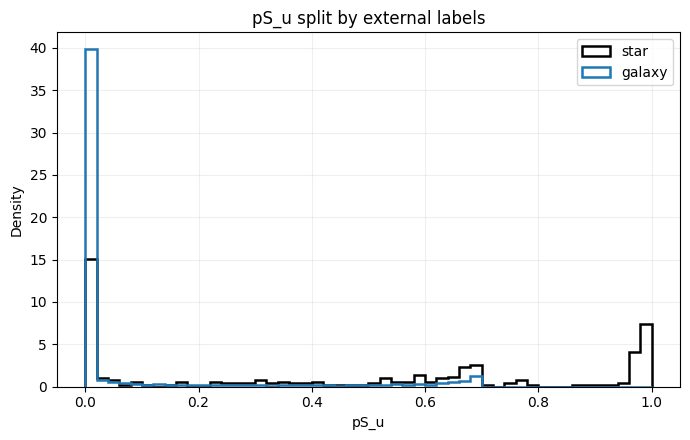

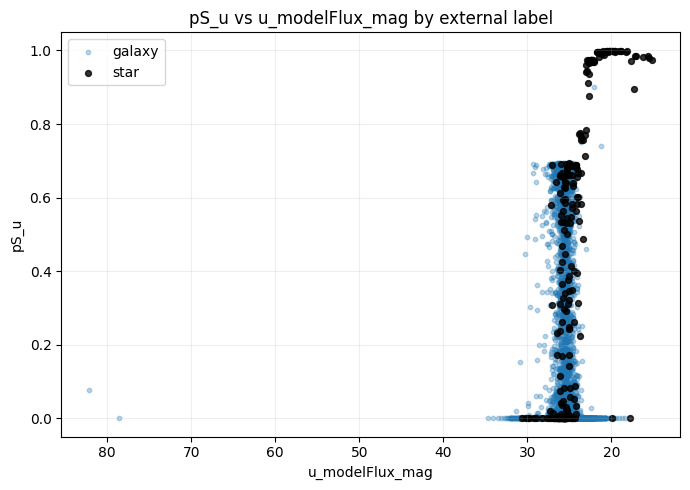

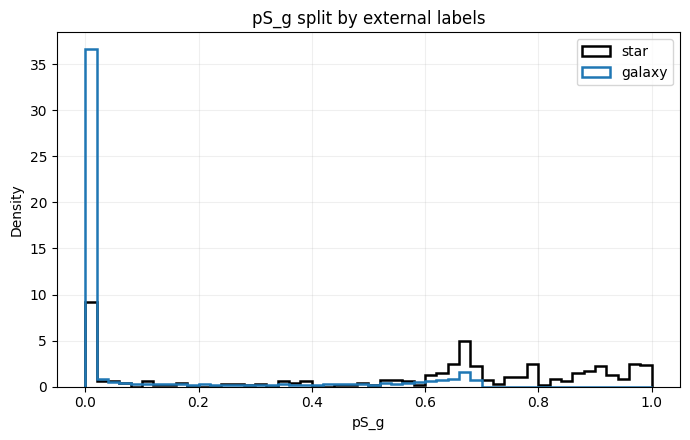

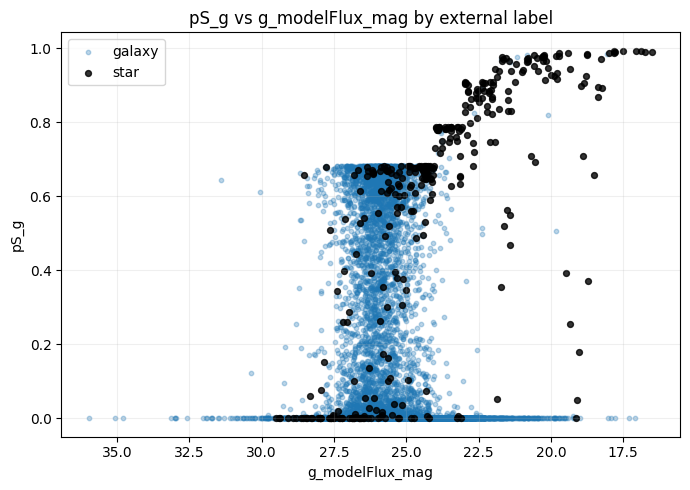

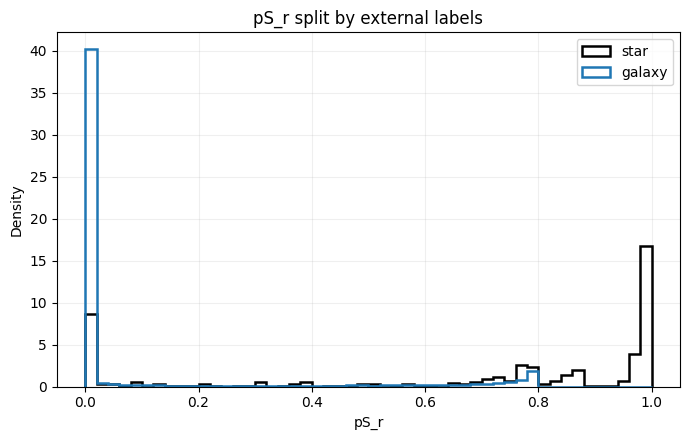

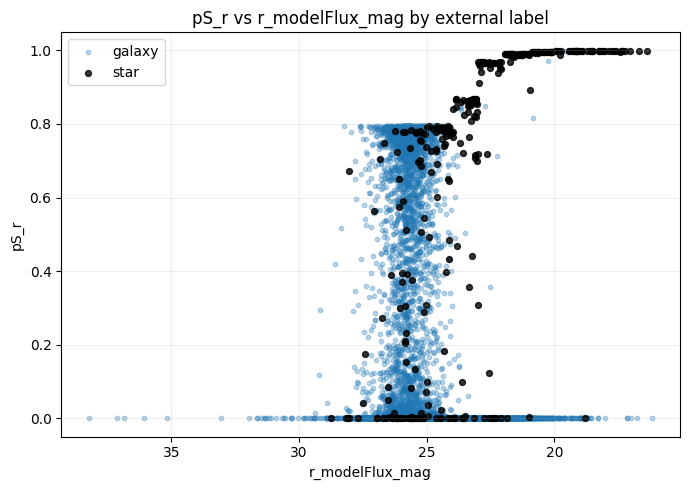

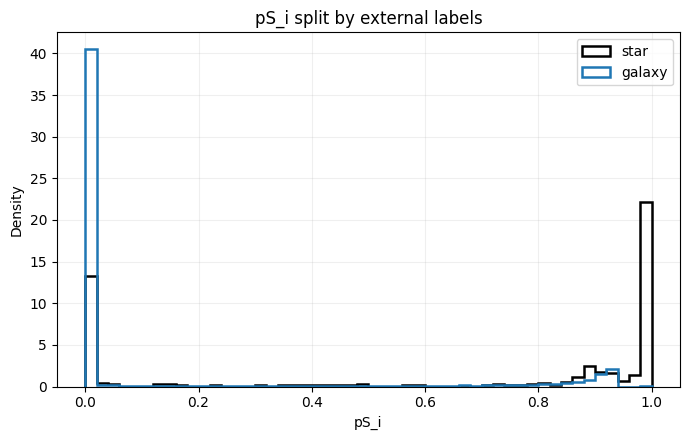

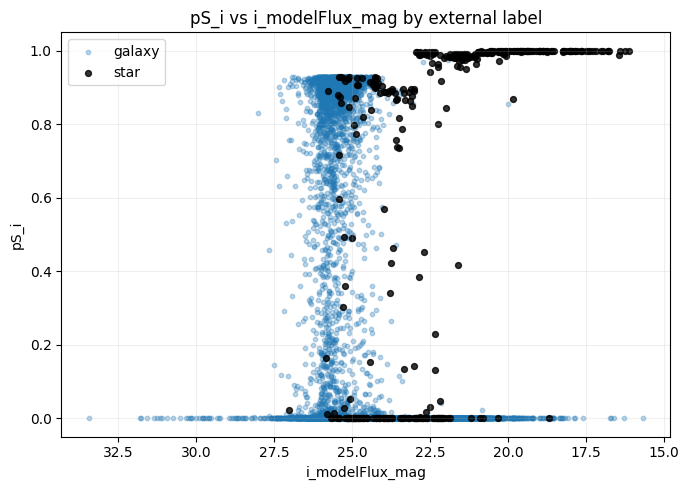

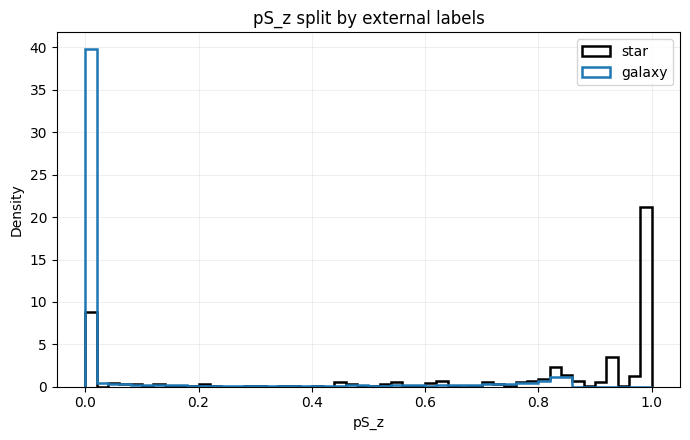

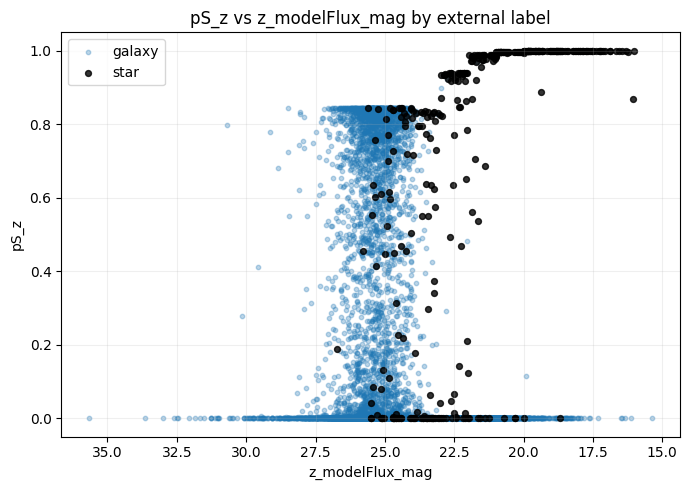

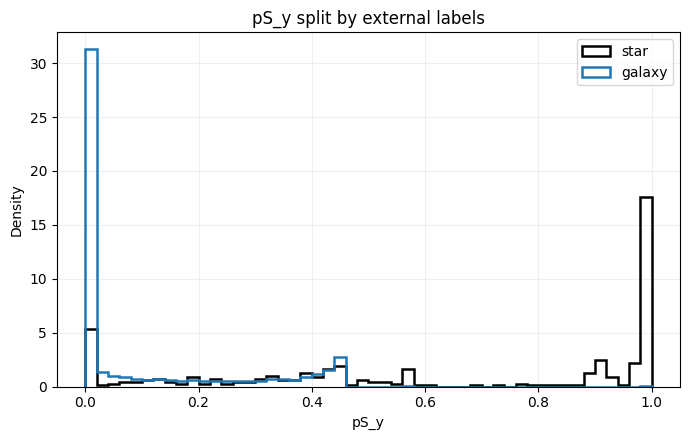

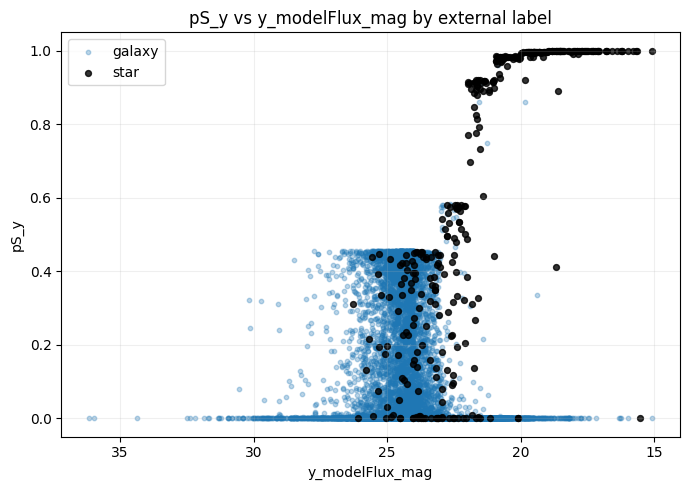

Generated per-band pS plot files:
   pS_hist_DP2v2_ECDFS_HST_u.png
   pS_vs_mag_DP2v2_ECDFS_HST_u.png
   pS_hist_DP2v2_ECDFS_HST_g.png
   pS_vs_mag_DP2v2_ECDFS_HST_g.png
   pS_hist_DP2v2_ECDFS_HST_r.png
   pS_vs_mag_DP2v2_ECDFS_HST_r.png
   pS_hist_DP2v2_ECDFS_HST_i.png
   pS_vs_mag_DP2v2_ECDFS_HST_i.png
   pS_hist_DP2v2_ECDFS_HST_z.png
   pS_vs_mag_DP2v2_ECDFS_HST_z.png
   pS_hist_DP2v2_ECDFS_HST_y.png
   pS_vs_mag_DP2v2_ECDFS_HST_y.png


In [23]:
generated_plot_files = []

for band in available_ps_bands:
    hist_name = f'pS_hist_DP2v2_ECDFS_HST_{band}.png'
    score_mag_name = f'pS_vs_mag_DP2v2_ECDFS_HST_{band}.png'

    elt.plot_score_hist_by_label(ecdfs_labeled_use, f'pS_{band}', name=hist_name)
    elt.plot_score_vs_mag_by_label(
        ecdfs_labeled_use, f'pS_{band}', f'{band}_modelFlux_mag', name=score_mag_name
    )

    generated_plot_files.extend([hist_name, score_mag_name])

print('Generated per-band pS plot files:')
for name in generated_plot_files:
    print('  ', name)

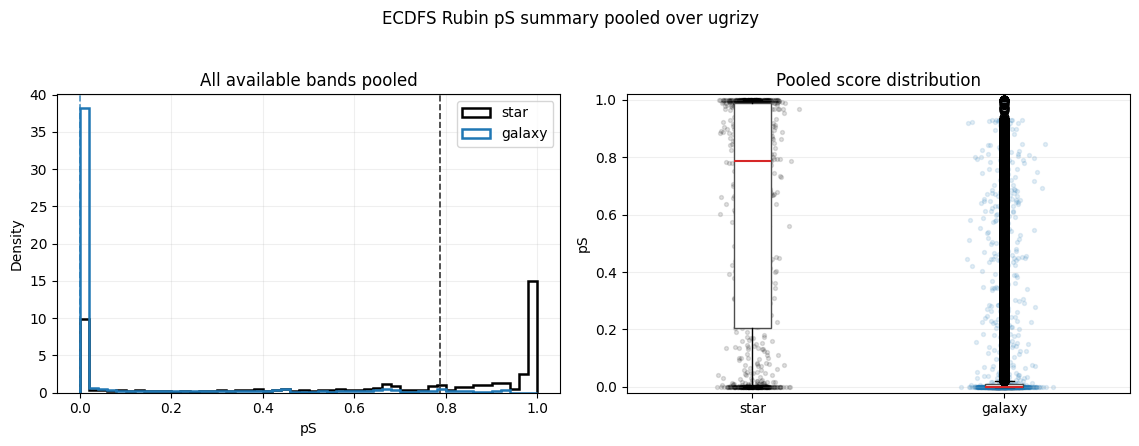

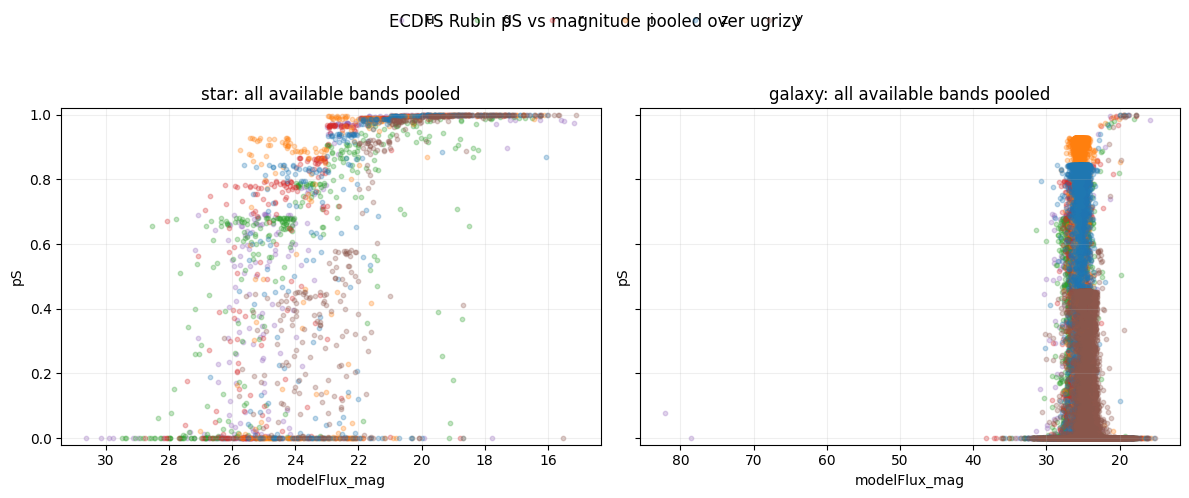

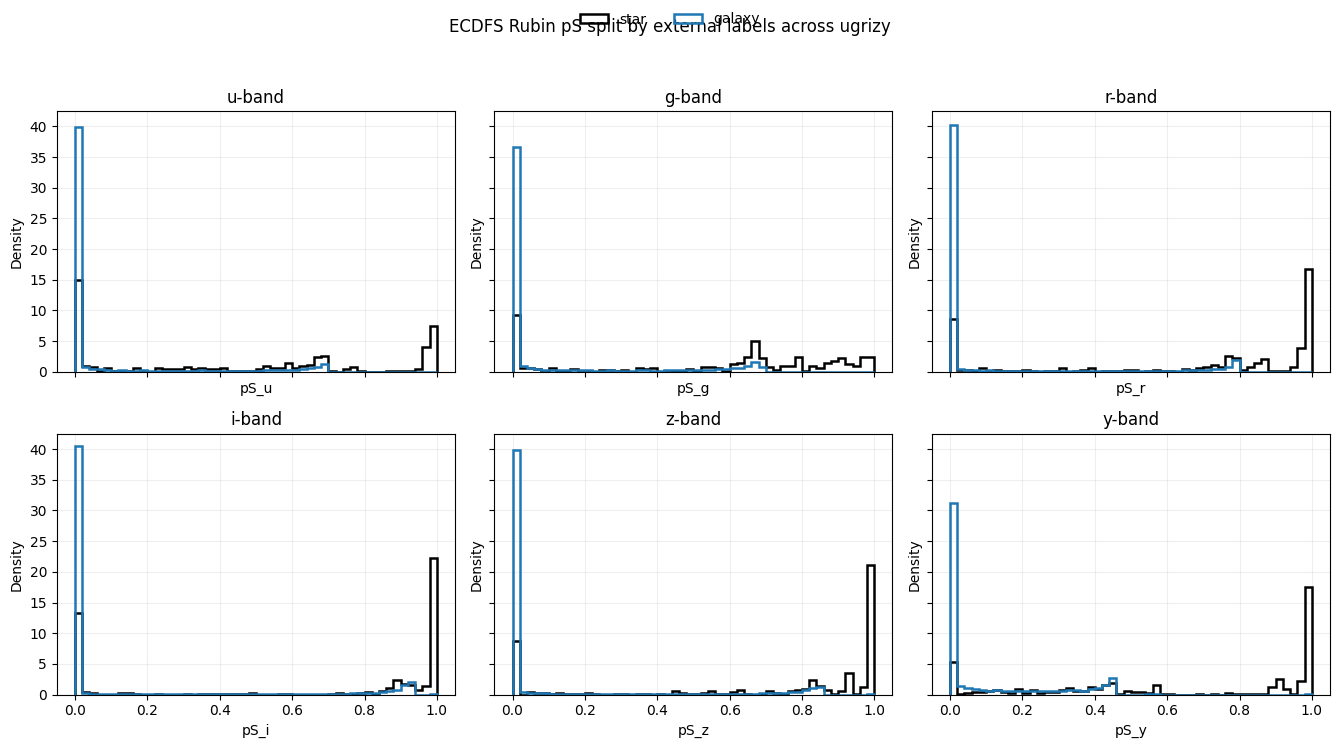

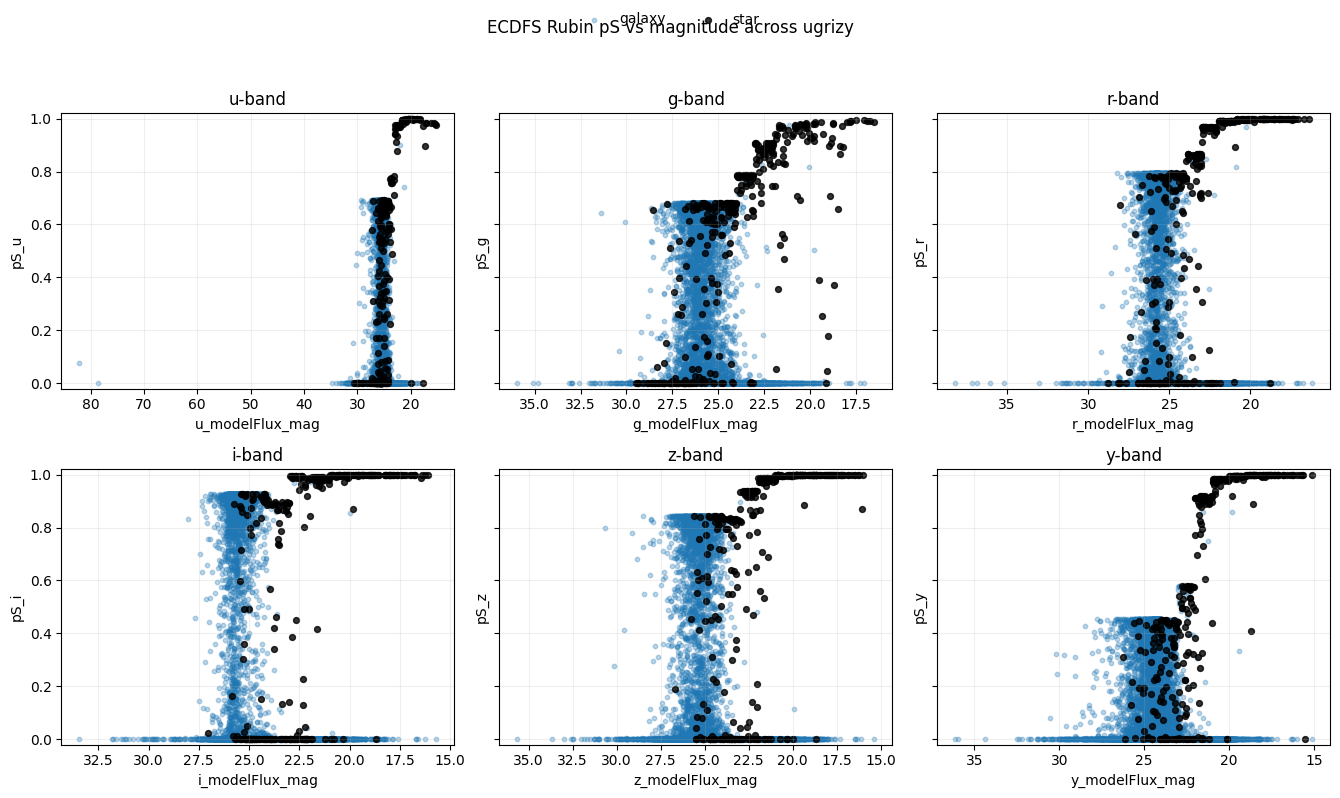

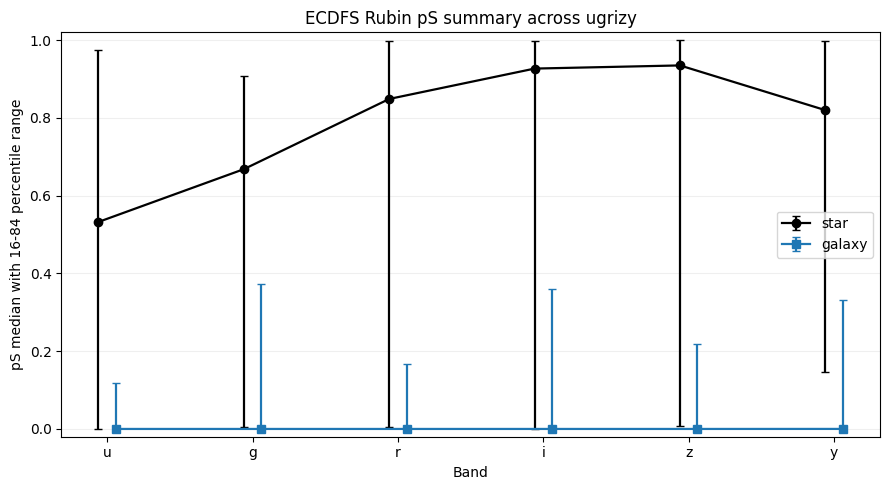

,band,label,count,mean,median,std,p16,p84
0,g,galaxy,13227,0.112225,9.014111e-12,0.221158,2.853507e-72,0.373356
1,g,star,341,0.564704,6.681068e-01,0.344925,5.499454e-03,0.907598
2,i,galaxy,13450,0.137815,3.916440e-153,0.309174,0.000000e+00,0.360214
3,i,star,347,0.660914,9.267818e-01,0.436460,1.835546e-12,0.998754
4,r,galaxy,13376,0.102652,1.400177e-54,0.239424,0.000000e+00,0.166754
5,r,star,346,0.678024,8.486693e-01,0.382716,5.118488e-03,0.996664
6,u,galaxy,9539,0.081110,1.801979e-16,0.193861,2.368535e-118,0.118919
7,u,star,256,0.461355,5.323867e-01,0.394021,1.611561e-08,0.974438
8,y,galaxy,10654,0.100608,7.542587e-05,0.159815,1.168201e-69,0.332856
9,y,star,344,0.631187,8.198808e-01,0.376076,1.454301e-01,0.998114


In [24]:
ps_band_summary = elt.summarize_multiband_scores(ecdfs_labeled_use, available_ps_bands)
ps_band_summary.to_csv('../data/ecdfs_dp2_ps_band_summary_v2.csv', index=False)

elt.plot_pooled_multiband_score_summary(
    ecdfs_labeled_use, available_ps_bands,
    name='pS_summary_DP2v2_ECDFS_HST_ugrizy.png',
)

elt.plot_pooled_multiband_score_vs_mag(
    ecdfs_labeled_use, available_ps_bands,
    name='pS_vs_mag_DP2v2_ECDFS_HST_ugrizy.png',
)

elt.plot_multiband_score_hist_grid(
    ecdfs_labeled_use, available_ps_bands,
    name='pS_hist_DP2v2_ECDFS_HST_ugrizy_grid.png',
)

elt.plot_multiband_score_vs_mag_grid(
    ecdfs_labeled_use, available_ps_bands,
    name='pS_vs_mag_DP2v2_ECDFS_HST_ugrizy_grid.png',
)

elt.plot_multiband_score_summary(
    ecdfs_labeled_use, available_ps_bands,
    name='pS_summary_by_band_DP2v2_ECDFS_HST_ugrizy.png',
)

ps_band_summary[['band', 'label', 'count', 'mean', 'median', 'std', 'p16', 'p84']]

## NATIVE RUBIN EXTENDEDNESS ADD-ON
This section keeps the existing `pS` workflow intact and adds the native Rubin `extendedness` quantity in parallel, using the same clean ECDFS external-label sample. If an `{band}_extendedness_flag` column exists, flagged values are excluded before plotting.

u: 2176 finite unflagged extendedness values
g: 7297 finite unflagged extendedness values
r: 8358 finite unflagged extendedness values
i: 12339 finite unflagged extendedness values
z: 7832 finite unflagged extendedness values
y: 3068 finite unflagged extendedness values


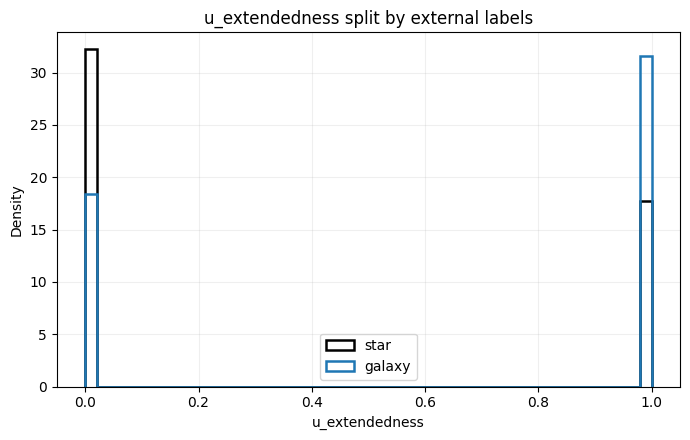

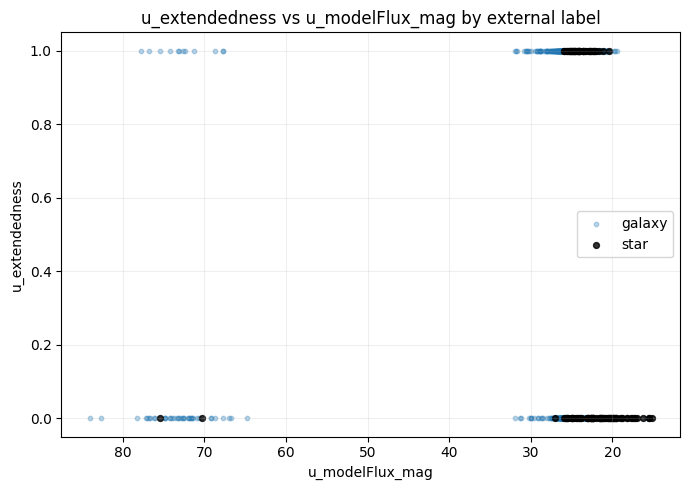

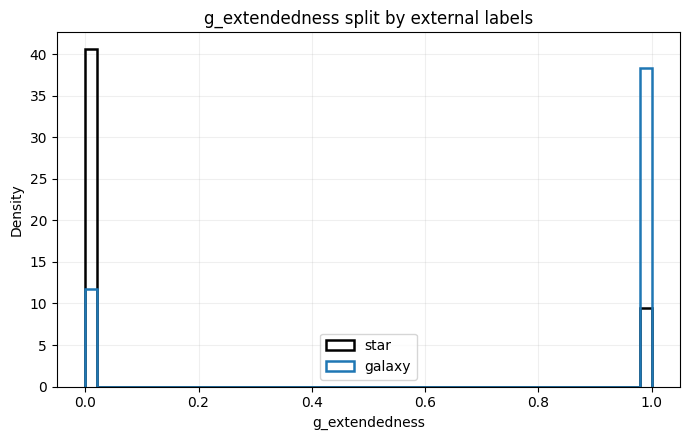

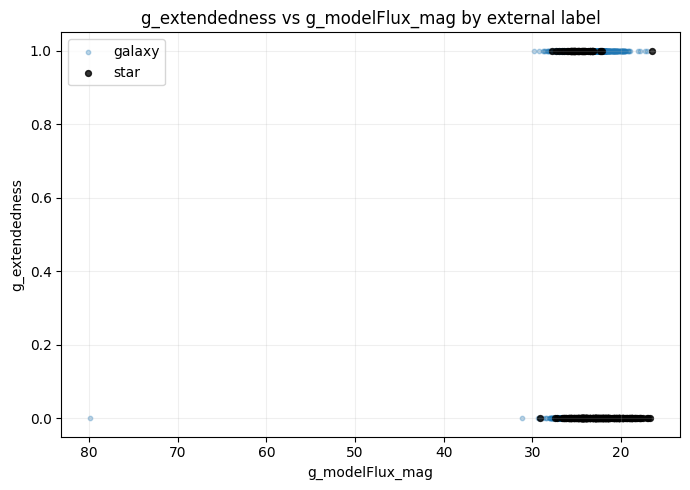

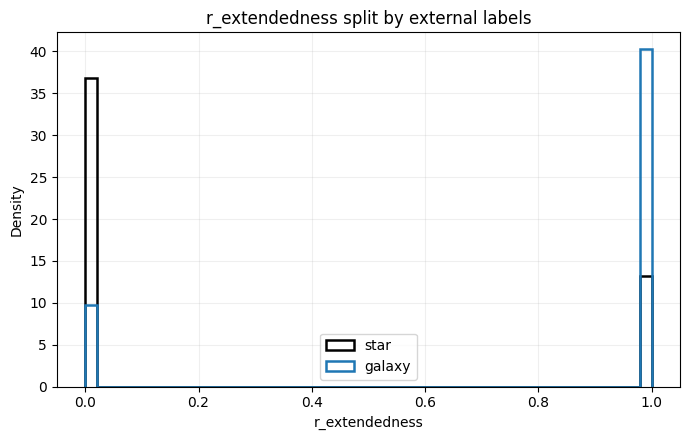

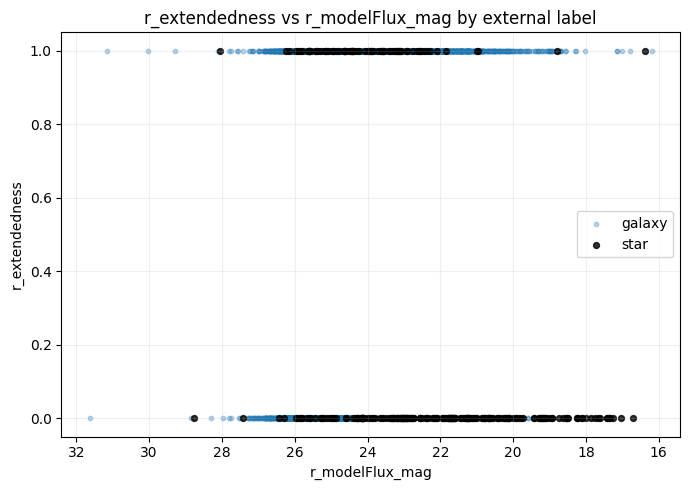

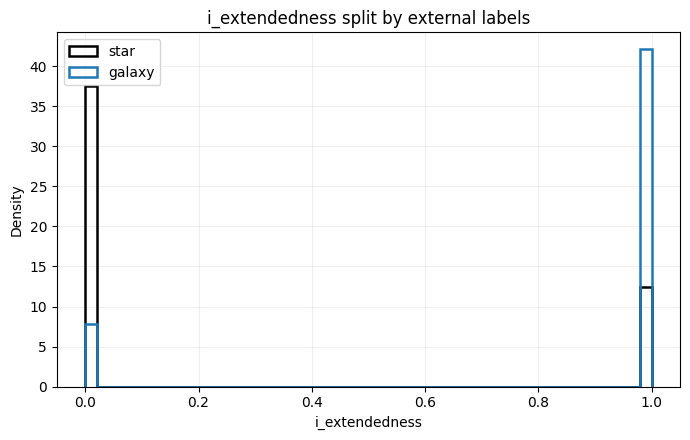

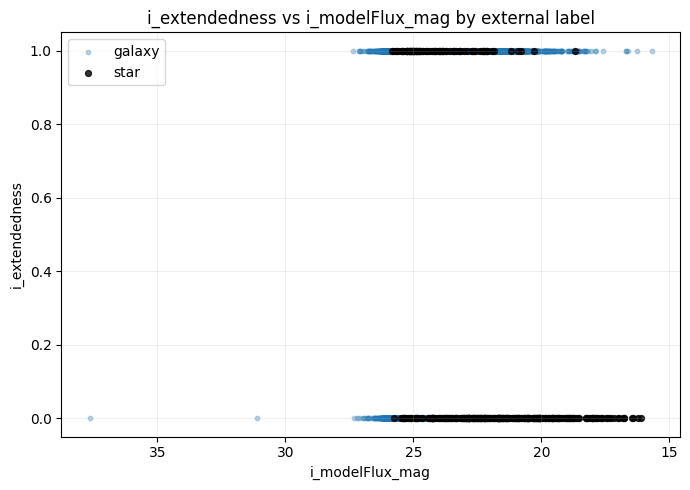

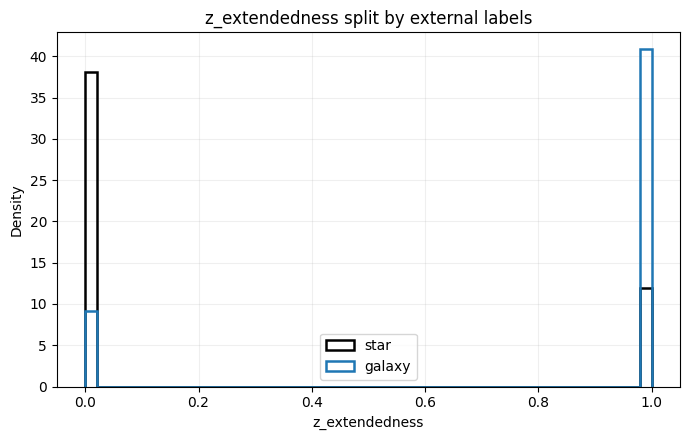

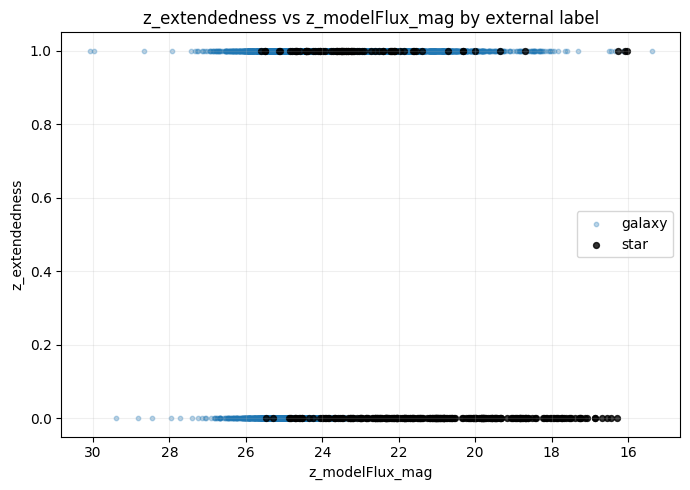

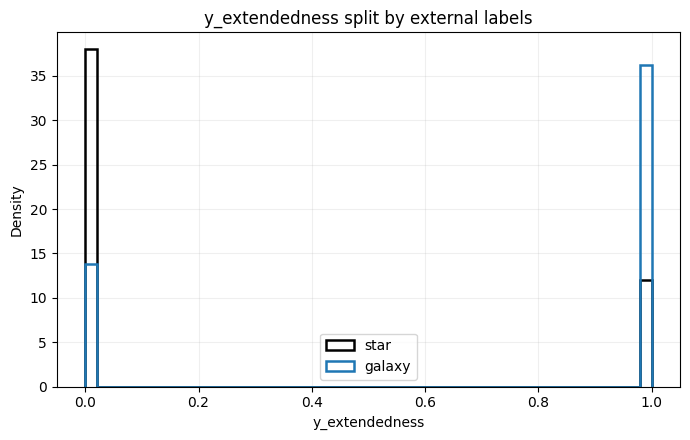

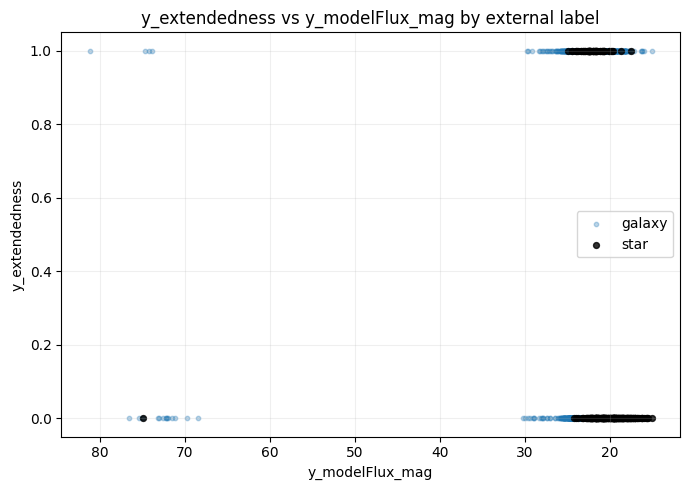

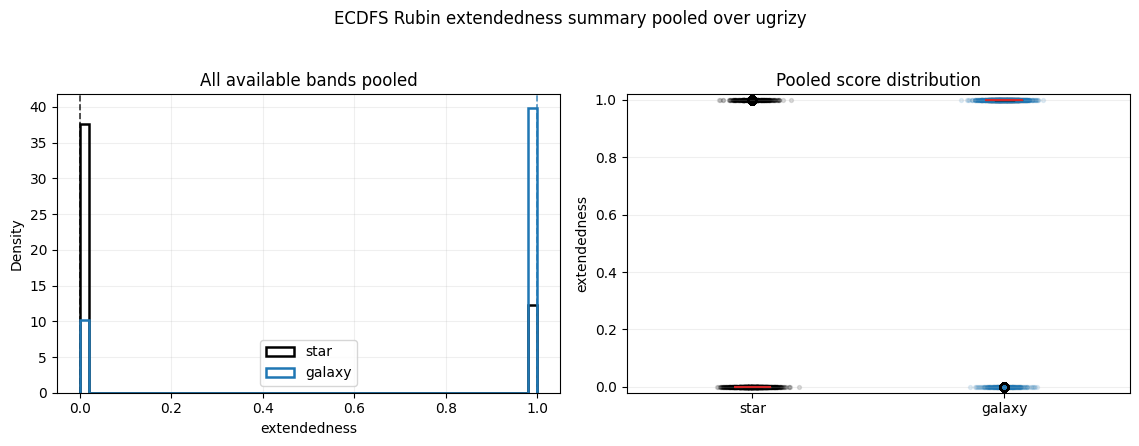

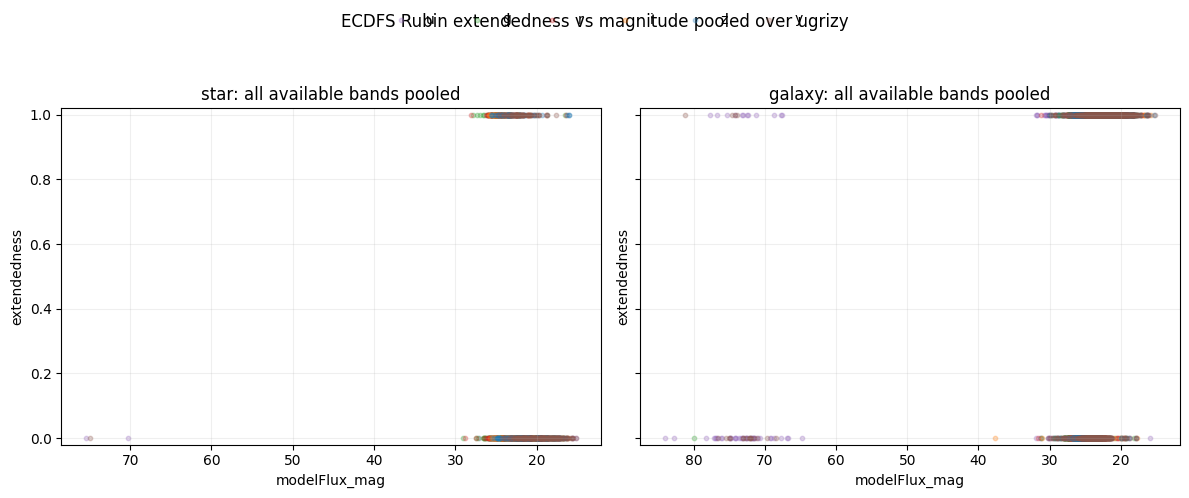

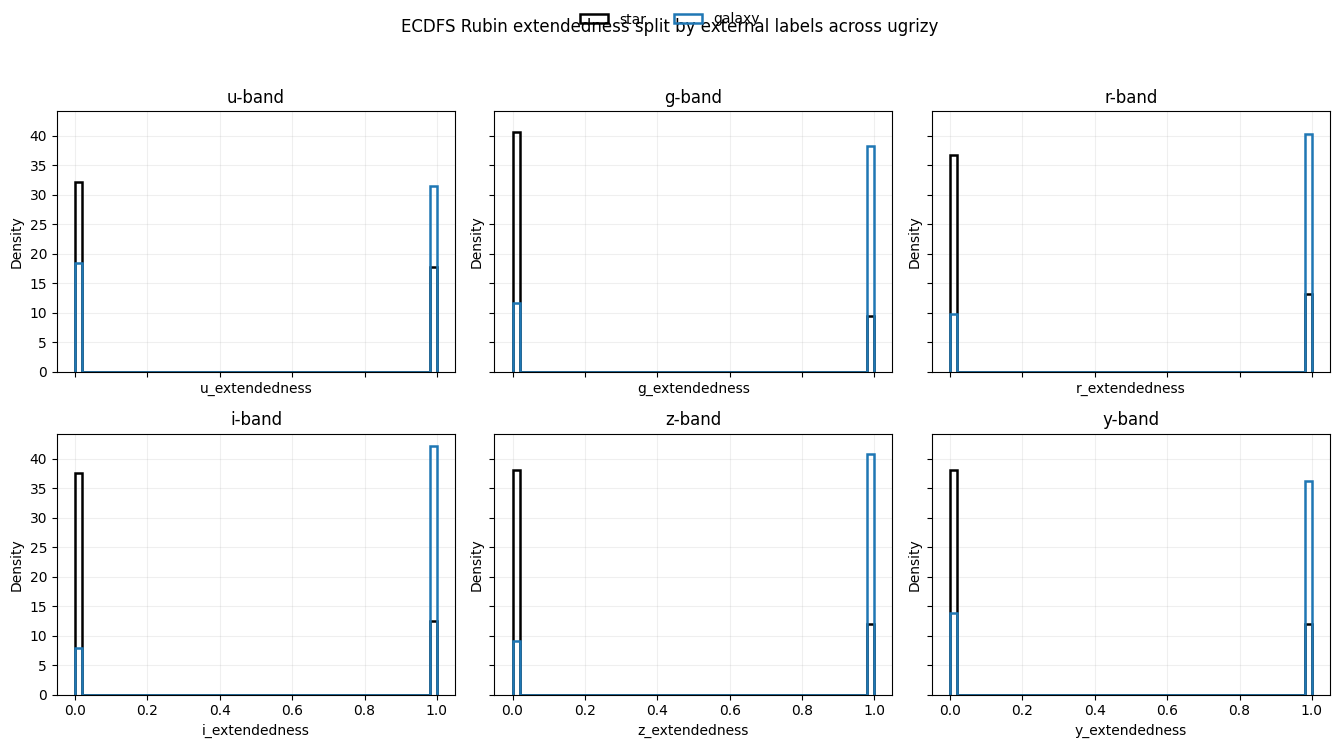

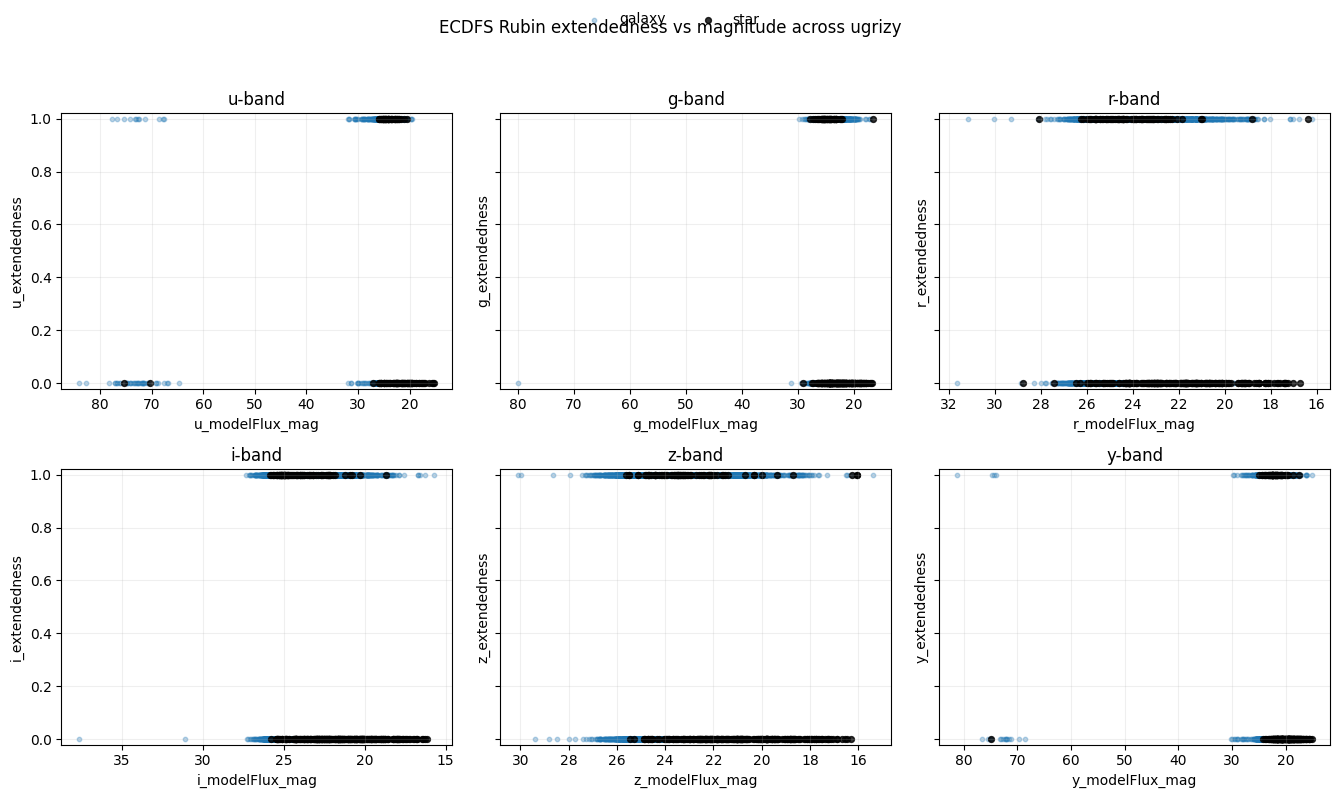

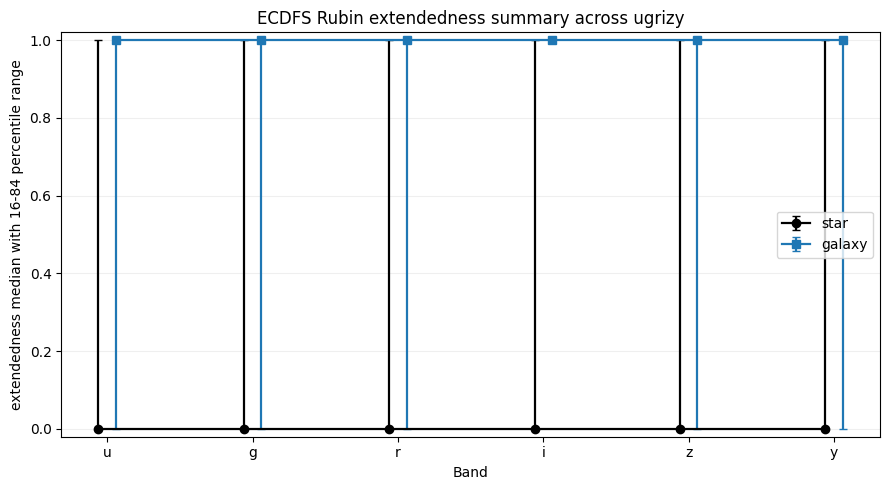

Generated per-band extendedness plot files:
   extendedness_hist_DP2v2_ECDFS_HST_u.png
   extendedness_vs_mag_DP2v2_ECDFS_HST_u.png
   extendedness_hist_DP2v2_ECDFS_HST_g.png
   extendedness_vs_mag_DP2v2_ECDFS_HST_g.png
   extendedness_hist_DP2v2_ECDFS_HST_r.png
   extendedness_vs_mag_DP2v2_ECDFS_HST_r.png
   extendedness_hist_DP2v2_ECDFS_HST_i.png
   extendedness_vs_mag_DP2v2_ECDFS_HST_i.png
   extendedness_hist_DP2v2_ECDFS_HST_z.png
   extendedness_vs_mag_DP2v2_ECDFS_HST_z.png
   extendedness_hist_DP2v2_ECDFS_HST_y.png
   extendedness_vs_mag_DP2v2_ECDFS_HST_y.png


,band,label,count,mean,median,std,p16,p84
0,g,galaxy,7042,0.765976,1.0,0.423418,0.0,1.0
1,g,star,255,0.188235,0.0,0.391669,0.0,1.0
2,i,galaxy,11997,0.842627,1.0,0.364167,1.0,1.0
3,i,star,342,0.248538,0.0,0.432799,0.0,1.0
4,r,galaxy,8059,0.805311,1.0,0.395986,0.0,1.0
5,r,star,299,0.264214,0.0,0.441653,0.0,1.0
6,u,galaxy,2055,0.631144,1.0,0.482612,0.0,1.0
7,u,star,121,0.355372,0.0,0.480616,0.0,1.0
8,y,galaxy,2818,0.723918,1.0,0.447137,0.0,1.0
9,y,star,250,0.240000,0.0,0.427940,0.0,1.0


In [25]:
ecdfs_extendedness_use = ecdfs_labeled_use.copy()
available_extendedness_bands = []

for band in all_ps_bands:
    ext_col = f'{band}_extendedness'
    mag_col = f'{band}_modelFlux_mag'
    flag_col = f'{band}_extendedness_flag'

    if ext_col not in ecdfs_extendedness_use.columns or mag_col not in ecdfs_extendedness_use.columns:
        print(f'Skipping {band} extendedness: missing Rubin columns')
        continue

    ext_values = pd.to_numeric(ecdfs_extendedness_use[ext_col], errors='coerce')
    if flag_col in ecdfs_extendedness_use.columns:
        good_flag = pd.to_numeric(ecdfs_extendedness_use[flag_col], errors='coerce').fillna(1).eq(0)
        ext_values = ext_values.where(good_flag)

    ecdfs_extendedness_use[ext_col] = ext_values
    n_good = int(np.isfinite(ext_values).sum())
    if n_good == 0:
        print(f'Skipping {band} extendedness: no finite unflagged values')
        continue

    available_extendedness_bands.append(band)
    print(f'{band}: {n_good} finite unflagged extendedness values')

if not available_extendedness_bands:
    raise ValueError('No usable Rubin extendedness bands found in the ECDFS DP2 labeled sample.')

generated_extendedness_plot_files = []
for band in available_extendedness_bands:
    hist_name = f'extendedness_hist_DP2v2_ECDFS_HST_{band}.png'
    score_mag_name = f'extendedness_vs_mag_DP2v2_ECDFS_HST_{band}.png'

    elt.plot_score_hist_by_label(
        ecdfs_extendedness_use, f'{band}_extendedness',
        bins=np.linspace(0, 1, 51), name=hist_name,
    )
    elt.plot_score_vs_mag_by_label(
        ecdfs_extendedness_use, f'{band}_extendedness',
        f'{band}_modelFlux_mag', name=score_mag_name,
    )

    generated_extendedness_plot_files.extend([hist_name, score_mag_name])

extendedness_band_summary = elt.summarize_multiband_scores(
    ecdfs_extendedness_use, available_extendedness_bands,
    score_prefix='', score_suffix='_extendedness',
)
extendedness_band_summary.to_csv('../data/ecdfs_dp2_extendedness_band_summary_v2.csv', index=False)

elt.plot_pooled_multiband_score_summary(
    ecdfs_extendedness_use, available_extendedness_bands,
    score_prefix='', score_suffix='_extendedness',
    score_label='extendedness',
    name='extendedness_summary_DP2v2_ECDFS_HST_ugrizy.png',
)

elt.plot_pooled_multiband_score_vs_mag(
    ecdfs_extendedness_use, available_extendedness_bands,
    score_prefix='', score_suffix='_extendedness',
    score_label='extendedness',
    name='extendedness_vs_mag_DP2v2_ECDFS_HST_ugrizy.png',
)

elt.plot_multiband_score_hist_grid(
    ecdfs_extendedness_use, available_extendedness_bands,
    score_prefix='', score_suffix='_extendedness',
    score_label='extendedness',
    name='extendedness_hist_DP2v2_ECDFS_HST_ugrizy_grid.png',
)

elt.plot_multiband_score_vs_mag_grid(
    ecdfs_extendedness_use, available_extendedness_bands,
    score_prefix='', score_suffix='_extendedness',
    score_label='extendedness',
    name='extendedness_vs_mag_DP2v2_ECDFS_HST_ugrizy_grid.png',
)

elt.plot_multiband_score_summary(
    ecdfs_extendedness_use, available_extendedness_bands,
    score_prefix='', score_suffix='_extendedness',
    score_label='extendedness',
    name='extendedness_summary_by_band_DP2v2_ECDFS_HST_ugrizy.png',
)

print('Generated per-band extendedness plot files:')
for name in generated_extendedness_plot_files:
    print('  ', name)

extendedness_band_summary[['band', 'label', 'count', 'mean', 'median', 'std', 'p16', 'p84']]

## DIRECT `pS` VS `extendedness` COMPARISON
For a direct comparison on the same clean ECDFS HST-labeled sample, we convert Rubin `extendedness` into a star-likeness score `1 - extendedness`, so both axes are high for point sources and low for galaxies.

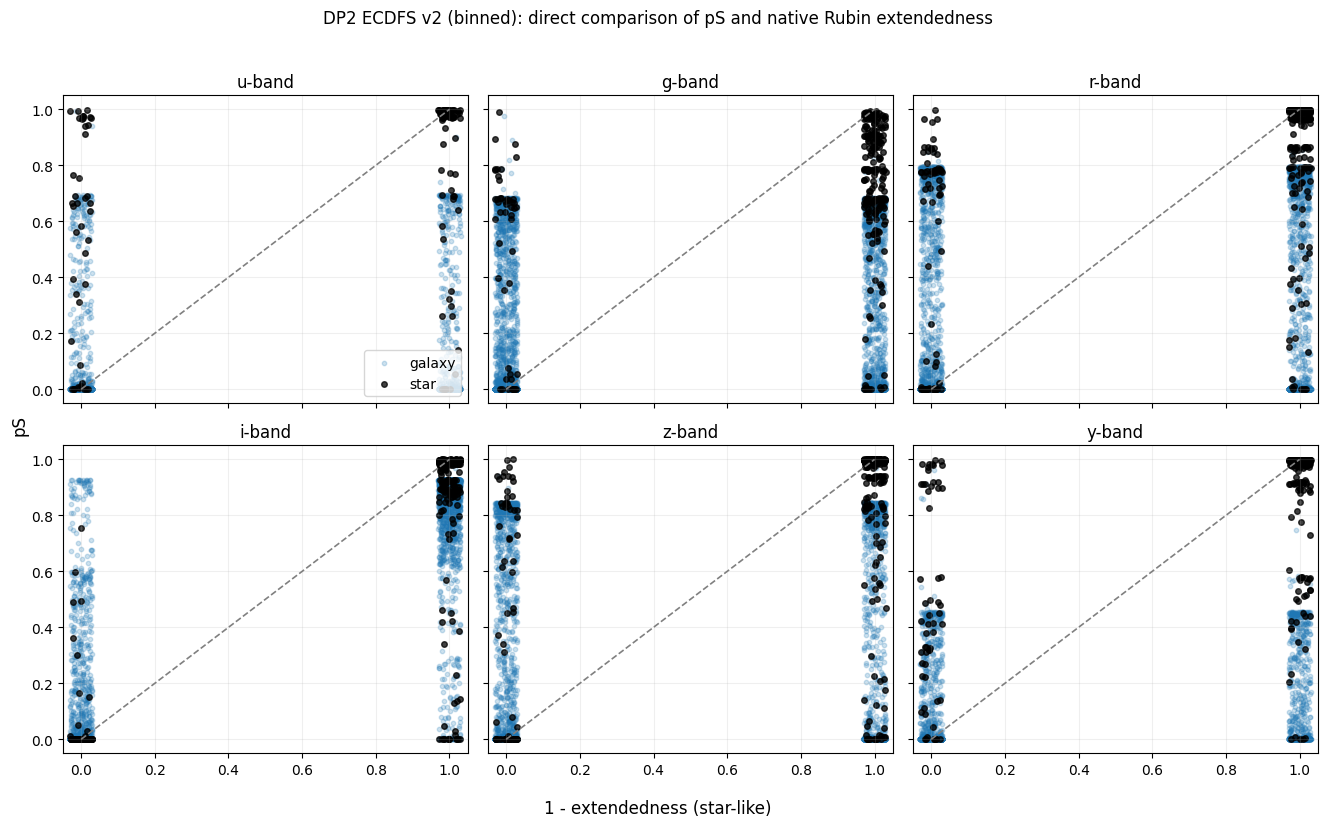

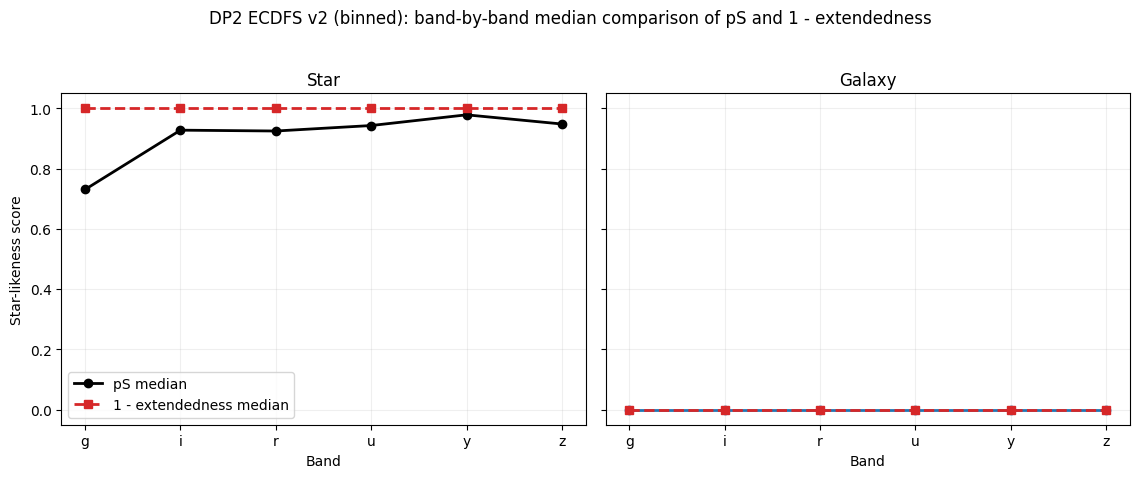

,band,label,count_common,pS_mean,pS_median,extendedness_mean,extendedness_median,extendedness_star_mean,extendedness_star_median,pearson_corr
0,g,galaxy,7038,0.117136,3.361677e-11,0.766269,1.0,0.233731,0.0,0.375118
1,i,galaxy,11995,0.142205,2.729740e-143,0.842684,1.0,0.157316,0.0,0.925588
2,r,galaxy,8057,0.103224,6.329095e-59,0.805387,1.0,0.194613,0.0,0.370038
3,u,galaxy,1925,0.097876,2.602906e-11,0.658701,1.0,0.341299,0.0,0.213732
4,y,galaxy,2738,0.079704,1.104211e-14,0.734843,1.0,0.265157,0.0,0.296970
5,z,galaxy,7513,0.103938,1.822341e-61,0.817250,1.0,0.182750,0.0,0.307720
6,g,star,255,0.687833,7.308527e-01,0.188235,0.0,0.811765,1.0,0.338308
7,i,star,342,0.670508,9.277522e-01,0.248538,0.0,0.751462,1.0,0.839651
8,r,star,298,0.758022,9.249435e-01,0.265101,0.0,0.734899,1.0,0.510538
9,u,star,117,0.707076,9.431151e-01,0.367521,0.0,0.632479,1.0,0.347183


In [26]:
compare_bands = [
    band for band in all_ps_bands
    if band in available_ps_bands and band in available_extendedness_bands
]
if not compare_bands:
    raise ValueError(
        'No common bands with both pS and extendedness available for direct comparison.'
    )

rng = np.random.default_rng(12345)
comparison_rows = []
fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.0), sharex=True, sharey=True)
axes = axes.ravel()

for ax, band in zip(axes, compare_bands):
    ps_col = f'pS_{band}'
    ext_col = f'{band}_extendedness'
    use = ecdfs_extendedness_use[
        np.isfinite(ecdfs_extendedness_use[ps_col])
        & np.isfinite(ecdfs_extendedness_use[ext_col])
        & ecdfs_extendedness_use['external_label'].isin(['star', 'galaxy'])
    ][['external_label', ps_col, ext_col]].copy()

    use['extendedness_star_score'] = 1.0 - use[ext_col]
    use['ext_star_score_jitter'] = np.clip(
        use['extendedness_star_score'] + rng.uniform(-0.03, 0.03, size=len(use)),
        -0.05, 1.05,
    )

    for label, color, alpha, size in [
        ('galaxy', 'tab:blue', 0.22, 10), ('star', 'black', 0.75, 16)
    ]:
        sub = use[use['external_label'] == label]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub['ext_star_score_jitter'], sub[ps_col],
            c=color, alpha=alpha, s=size, label=label,
        )

    ax.plot([0, 1], [0, 1], ls='--', lw=1.2, color='0.5')
    ax.set_title(f'{band}-band')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.2)

    for label in ['star', 'galaxy']:
        sub = use[use['external_label'] == label]
        if len(sub) == 0:
            continue
        comparison_rows.append({
            'band': band,
            'label': label,
            'count_common': int(len(sub)),
            'pS_mean': float(sub[ps_col].mean()),
            'pS_median': float(sub[ps_col].median()),
            'extendedness_mean': float(sub[ext_col].mean()),
            'extendedness_median': float(sub[ext_col].median()),
            'extendedness_star_mean': float((1.0 - sub[ext_col]).mean()),
            'extendedness_star_median': float((1.0 - sub[ext_col]).median()),
            'pearson_corr': (
                float(sub[ps_col].corr(1.0 - sub[ext_col]))
                if len(sub) > 1 else np.nan
            ),
        })

for ax in axes[len(compare_bands):]:
    ax.set_visible(False)

axes[0].legend(loc='lower right', frameon=True)
fig.supxlabel('1 - extendedness (star-like)')
fig.supylabel('pS')
fig.suptitle(
    'DP2 ECDFS v2 (binned): direct comparison of pS and native Rubin extendedness',
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    '../plots/pS_vs_extendedness_DP2v2_ECDFS_HST_ugrizy_grid.png',
    dpi=200, bbox_inches='tight',
)
plt.show()

ps_ext_compare = (
    pd.DataFrame(comparison_rows)
    .sort_values(['label', 'band'])
    .reset_index(drop=True)
)
ps_ext_compare.to_csv(
    '../data/ecdfs_dp2_ps_extendedness_comparison_summary_v2.csv', index=False
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=True)
for ax, label, color in [
    (axes[0], 'star', 'black'), (axes[1], 'galaxy', 'tab:blue')
]:
    sub = ps_ext_compare[ps_ext_compare['label'] == label].sort_values('band')
    ax.plot(
        sub['band'], sub['pS_median'],
        marker='o', lw=2.0, color=color, label='pS median',
    )
    ax.plot(
        sub['band'], sub['extendedness_star_median'],
        marker='s', lw=2.0, ls='--', color='tab:red',
        label='1 - extendedness median',
    )
    ax.set_title(label.title())
    ax.set_xlabel('Band')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Star-likeness score')
axes[0].legend(loc='best')
fig.suptitle(
    'DP2 ECDFS v2 (binned): band-by-band median comparison of pS and 1 - extendedness',
    y=1.03,
)
plt.tight_layout()
plt.savefig(
    '../plots/pS_vs_extendedness_summary_DP2v2_ECDFS_HST_ugrizy.png',
    dpi=200, bbox_inches='tight',
)
plt.show()

ps_ext_compare